reading in the catlaogs 

### General Tutorial 

In [ ]:
from astropy.io import fits
import astropy.table as table
from astropy.table import vstack
from astropy.table import QTable, Column, MaskedColumn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import astropy.units as u
import astropy.constants as c

import glob
from astroquery.vizier import Vizier
from astropy.coordinates import SkyCoord
from astropy.coordinates import Angle
from astropy.coordinates import search_around_sky

import concurrent.futures
import time
import random





In [3]:
catalog_home_dir = '/Users/mario/Coding/nrao_reu_research/socorro/USSCataloging/catalogs/'


In [3]:
cosmos_irac = QTable.read(catalog_home_dir + 'COSMOS_IRAC.fits', format ='fits')
cosmos_opt  = QTable.read(catalog_home_dir + 'COSMOS_OPTICAL.fits', format ='fits')
cosmos_xmm  = QTable.read(catalog_home_dir + 'COSMOS_XMM.fits', format ='fits')

In [15]:
cosmos_xmm

ID,RA,DEC,pos_err
int32,float64,float64,float32
1,150.1051483,1.9808168,0.91
2,149.7391899,2.2205331,0.93
3,149.7615427,2.3184922,0.9
4,149.7441813,2.249476,0.97
5,149.8281899,2.1642078,0.93
6,150.179776,2.1101542,0.96
7,150.5210769,2.625247,0.91
8,150.0538298,2.5896702,0.98
9,149.9198279,2.3274745,1.0


In [9]:
output_table = QTable.read(catalog_home_dir + 'example1.fits', format ='fits')

In [12]:
output_table[output_table['XMM_ID'] == 1]

XMM_ID,XMM_RA,XMM_DEC,XMM_pos_err,OPT_ID,OPT_RA,OPT_DEC,OPT_MAG,IRAC_ID,IRAC_RA,IRAC_DEC,IRAC_mag_ch1,IRAC_err_ch1,Separation_OPT_XMM,Separation_IRAC_XMM,Separation_IRAC_OPT,Separation_max,ncat,dist_bayesfactor,dist_bayesfactor_corrected,dist_post,p_single,p_any,p_i,match_flag
int32,float64,float64,float32,int32,float64,float64,float32,int32,float64,float64,float32,float64,float32,float32,float32,float32,int16,float32,float32,float32,float32,float32,float32,int16
1,150.1051483,1.9808168,0.91,-99,-99.0,-99.0,-99.0,-99,-99.0,-99.0,-99.0,-99.0,--,--,--,0.0,1,0.0,2.6934237,1.0,1.0,0.7469592,0.0,0
1,150.1051483,1.9808168,0.91,-99,-99.0,-99.0,-99.0,116970,150.103722,1.977713,23.3769,0.075487,--,12.295715,--,12.295715,2,-28.164541,-28.164541,9.113611e-39,9.113611e-39,0.7469592,6.254e-42,0
1,150.1051483,1.9808168,0.91,-99,-99.0,-99.0,-99.0,116980,150.106543,1.977976,22.3098,0.0288691,--,11.391603,--,11.391603,2,-22.615774,-22.615774,3.2244655e-33,3.2244655e-33,0.7469592,2.2127257e-36,0
1,150.1051483,1.9808168,0.91,-99,-99.0,-99.0,-99.0,117023,150.105591,1.978009,22.8504,0.0470996,--,10.2328,--,10.2328,2,-16.123266,-16.123266,1.00222644e-26,1.00222644e-26,0.7469592,6.877581e-30,0
1,150.1051483,1.9808168,0.91,-99,-99.0,-99.0,-99.0,117256,150.107248,1.97914,21.6994,0.0183716,--,9.669962,--,9.669962,2,-13.2208805,-13.2208805,8.004809e-24,8.004809e-24,0.7469592,5.493142e-27,0
1,150.1051483,1.9808168,0.91,-99,-99.0,-99.0,-99.0,117382,150.103656,1.979511,22.2559,0.0274885,--,7.13619,--,7.13619,2,-2.187864,-2.187864,8.637096e-13,8.637096e-13,0.7469592,5.927037e-16,0
1,150.1051483,1.9808168,0.91,-99,-99.0,-99.0,-99.0,117474,150.105733,1.979993,20.831,0.00829443,--,3.6360219,--,3.6360219,2,7.5811834,7.5811834,0.0050491337,0.0050491337,0.7469592,3.4824518e-06,0
1,150.1051483,1.9808168,0.91,-99,-99.0,-99.0,-99.0,117598,150.108555,1.979648,18.8906,0.00236741,--,12.9589205,--,12.9589205,2,-32.50412,-32.50412,4.18e-43,4.18e-43,0.7469592,0.0,0
1,150.1051483,1.9808168,0.91,-99,-99.0,-99.0,-99.0,117728,150.105208,1.981163,17.1839,0.00130186,--,1.2646933,--,1.2646933,2,10.5921755,10.5921755,0.8388355,0.8388355,0.7469592,0.0035717192,0


### Messing with OWN Data  

## Distance Matching 

In [3]:
catalog_fermi_nway = '/Users/mario/Coding/nrao_reu_research/socorro/USSCataloging/reduced_catalogs/temp_nway_files/'


In [351]:
bay_table = QTable.read(catalog_fermi_nway+'4FGL_J0041.3-0048_bay.fits', format='fits')

In [ ]:
# adding the ra and dec error 
center_ra  = bay_table['FERMI_RAJ2000'][0]
center_dec = bay_table['FERMI_DECJ200'][0]

bay_table['ra_diff'] = (bay_table['MALS_L_RAJ2000'] - center_ra)
bay_table['dec_diff'] = (bay_table['MALS_L_DECJ200'] - center_dec)


In [353]:
bay_step_1 = bay_table[bay_table['match_flag'] ==1]

In [354]:
index_max_prob = np.argmax(bay_step_1['p_i'])
bay_step_2 = bay_step_1[index_max_prob]

##### matplot plotting

In [356]:
angle = bay_step_2['FERMI_Conf_95_PosAng']

Text(0.5, 1.0, 'Ellipse: 4FGL J0041.3-0048 MALS distance-based matching')

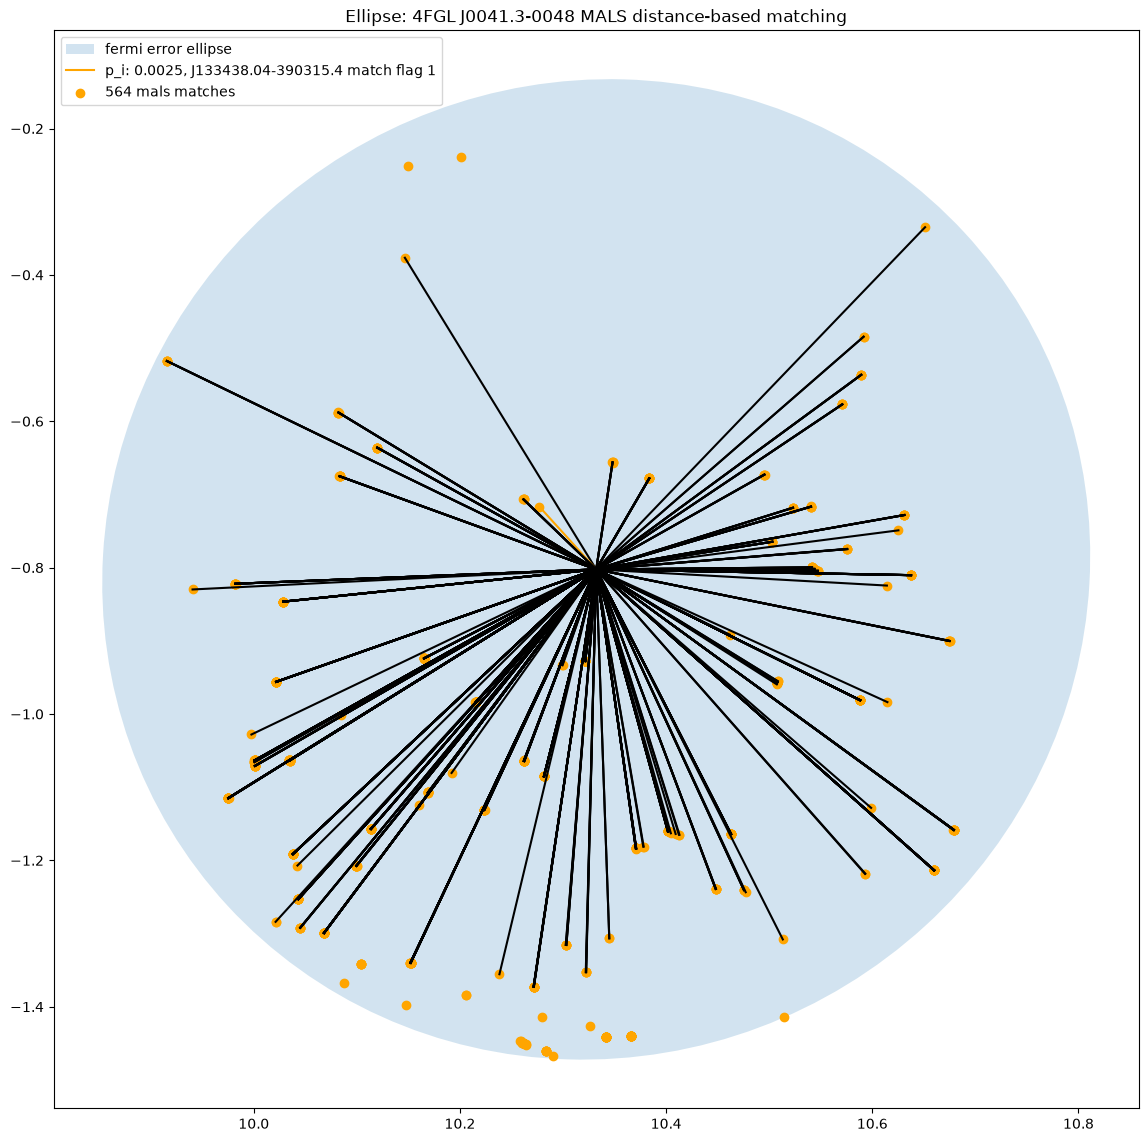

In [358]:
# position plot of the actual positions 
fig, ax = plt.subplots(figsize=(14,14))
# scatter the fermi ra and dec
# ax.scatter(bay_step_2['FERMI_RAJ2000'], bay_step_2['FERMI_RAJ2000'])
ellipse = patches.Ellipse((bay_step_2['FERMI_RAJ2000'], bay_step_2['FERMI_DECJ200']), bay_step_2['FERMI_Conf_95_SemiMajor']*2, bay_step_2['FERMI_Conf_95_SemiMinor']*2,
                          angle=angle, alpha=0.2, label='fermi error ellipse')

# color coding
# 

ax.add_patch(ellipse)
for source in bay_table:
    if source['match_flag'] == 1:
        ax.plot([source['FERMI_RAJ2000'], source['MALS_L_RAJ2000']],[source['FERMI_DECJ200'], source['MALS_L_DECJ200']],
                color='orange', label=f'p_i: {source['p_i']:.4f}, {source['MALS_L_spw_matches']} match flag 1')
    elif source['match_flag'] == 2:
        ax.plot([source['FERMI_RAJ2000'], source['MALS_L_RAJ2000'] ],[source['FERMI_DECJ200'], source['MALS_L_DECJ200']], color='black')

ax.scatter(bay_table[1:]['MALS_L_RAJ2000'], bay_table[1:]['MALS_L_DECJ200'], color ='orange', label=f'{len(bay_table[1:])} mals matches')
ax.legend(loc='best')
plt.savefig('dist_match_4FGL_J0041.3-0048_bay.png')
plt.title(f'Ellipse: {bay_table[0]['FERMI_Source_Name']} MALS distance-based matching')
# the highest prob source! 


In [ ]:
# position err plot of the sources 

In [42]:
bay_step_2

np.float32(0.0024664605)

In [ ]:
bay_table

FERMI_Source_Name,FERMI_DataRelease,FERMI_RAJ2000,FERMI_DECJ200,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Extended_Source_Name,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_LP_EPeak,FERMI_Unc_LP_EPeak,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_Unc_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_PLEC_EPeak,FERMI_Unc_PLEC_EPeak,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_ASSOC_4FGL,FERMI_ASSOC_FGL,FERMI_ASSOC_FHL,FERMI_ASSOC_GAM1,FERMI_ASSOC_GAM2,FERMI_ASSOC_GAM3,FERMI_TEVCAT_FLAG,FERMI_ASSOC_TEV,FERMI_CLASS1,FERMI_CLASS2,FERMI_ASSOC1,FERMI_ASSOC2,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_RA_Counterpart,FERMI_DEC_Counterpart,FERMI_Unc_Counterpart,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_id_x,FERMI_pointing_name,FERMI_obs_date_u,FERMI_obs_date_l,FERMI_obs_band,FERMI_pbeam_version,FERMI_fluxcal,FERMI_fluxscale,FERMI_spw_id,FERMI_ref_freq,FERMI_maj_restoring_beam,FERMI_min_restoring_beam,FERMI_pa_restoring_beam,FERMI_sigma_1,FERMI_sigma_2,FERMI_sigma_20,FERMI_source_id,FERMI_metadata_id,FERMI_source_name,FERMI_distance_pointing,FERMI_distance_nn,FERMI_s_code,FERMI_n_gauss,FERMI_maxsep_gauss,FERMI_maj,FERMI_maj_e,FERMI_min,FERMI_min_e,FERMI_pa,FERMI_pa_e,FERMI_dc_maj,FERMI_dc_maj_e,FERMI_dc_min,FERMI_dc_min_e,FERMI_dc_pa,FERMI_dc_pa_e,FERMI_ra_mean_e,FERMI_dec_mean_e,FERMI_ra_max,FERMI_ra_max_e,FERMI_dec_max,FERMI_dec_max_e,FERMI_total_flux,FERMI_total_flux_e,FERMI_total_flux_e_fit,FERMI_total_flux_e_sys,FERMI_total_flux_measured,FERMI_total_flux_measured_e,FERMI_peak_flux,FERMI_peak_flux_e,FERMI_isl_total_flux,FERMI_isl_total_flux_e,FERMI_isl_rms,FERMI_isl_mean,FERMI_resid_isl_rms,FERMI_resid_isl_mean,FERMI_flux_correction,FERMI_real_source,FERMI_resolved,FERMI_source_linked,FERMI_id_y,FERMI_spectral_index,FERMI_spectral_index_e,FERMI_spectral_index_spwused,FERMI_spectral_index_spwfit,FERMI_spectral_index_spwfit_e,FERMI_spectral_index_mals_lit,FERMI_spectral_index_mals_lit_e,FERMI_spectral_index_lit,FERMI_FluxRatio,FERMI_spw_matches,FERMI_pos_err,FERMI_ID,MALS_L_Source_Name,MALS_L_DataRelease,MALS_L_RAJ2000,MALS_L_DECJ200,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Extended_Source_Name,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS_L_SpectrumType,MALS_L_PL_Flux_Density,MALS_L_Unc_PL_Flux_Density,MALS_L_PL_Index,MALS_L_Unc_PL_Index,MALS_L_LP_Flux_Density,MALS_L_Unc_LP_Flux_Density,MALS_L_LP_Index,MALS_L_Unc_LP_Index,MALS_L_LP_beta,MALS_L_Unc_LP_beta,MALS_L_LP_SigCurv,MALS_L_LP_EPeak,MALS_L_Unc_LP_EPeak,MALS_L_PLEC_Flux_Density,MALS_L_Unc_PLEC_Flux_Density,MALS_L_PLEC_IndexS,MALS_L_Unc_PLEC_IndexS,MALS_L_PLEC_ExpfactorS,MALS_L_Unc_PLEC_ExpfactorS,MALS_L_PLEC_Exp_Index,MALS_L_Unc_PLEC_Exp_Index,MALS_L_PLEC_SigCurv,MALS_L_PLEC_EPeak,MALS_L_Unc_PLEC_EPeak,MALS_L_Npred,MALS_L_Flux_Band,MALS_L_Unc_Flux_Band,MALS_L_nuFnu_Band,MALS_L_Sqrt_TS_Band,MALS_L_Variability_Index,MALS_L_Frac_Variability,MALS_L_Unc_Frac_Variability,MALS_L_Signif_Peak,MALS_L_Flux_Peak,MALS_L_Unc_Flux_Peak,MALS_

In [132]:
bay_step_2

FERMI_Source_Name,FERMI_DataRelease,FERMI_RAJ2000,FERMI_DECJ200,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Extended_Source_Name,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_LP_EPeak,FERMI_Unc_LP_EPeak,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_Unc_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_PLEC_EPeak,FERMI_Unc_PLEC_EPeak,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_ASSOC_4FGL,FERMI_ASSOC_FGL,FERMI_ASSOC_FHL,FERMI_ASSOC_GAM1,FERMI_ASSOC_GAM2,FERMI_ASSOC_GAM3,FERMI_TEVCAT_FLAG,FERMI_ASSOC_TEV,FERMI_CLASS1,FERMI_CLASS2,FERMI_ASSOC1,FERMI_ASSOC2,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_RA_Counterpart,FERMI_DEC_Counterpart,FERMI_Unc_Counterpart,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_id_x,FERMI_pointing_name,FERMI_obs_date_u,FERMI_obs_date_l,FERMI_obs_band,FERMI_pbeam_version,FERMI_fluxcal,FERMI_fluxscale,FERMI_spw_id,FERMI_ref_freq,FERMI_maj_restoring_beam,FERMI_min_restoring_beam,FERMI_pa_restoring_beam,FERMI_sigma_1,FERMI_sigma_2,FERMI_sigma_20,FERMI_source_id,FERMI_metadata_id,FERMI_source_name,FERMI_distance_pointing,FERMI_distance_nn,FERMI_s_code,FERMI_n_gauss,FERMI_maxsep_gauss,FERMI_maj,FERMI_maj_e,FERMI_min,FERMI_min_e,FERMI_pa,FERMI_pa_e,FERMI_dc_maj,FERMI_dc_maj_e,FERMI_dc_min,FERMI_dc_min_e,FERMI_dc_pa,FERMI_dc_pa_e,FERMI_ra_mean_e,FERMI_dec_mean_e,FERMI_ra_max,FERMI_ra_max_e,FERMI_dec_max,FERMI_dec_max_e,FERMI_total_flux,FERMI_total_flux_e,FERMI_total_flux_e_fit,FERMI_total_flux_e_sys,FERMI_total_flux_measured,FERMI_total_flux_measured_e,FERMI_peak_flux,FERMI_peak_flux_e,FERMI_isl_total_flux,FERMI_isl_total_flux_e,FERMI_isl_rms,FERMI_isl_mean,FERMI_resid_isl_rms,FERMI_resid_isl_mean,FERMI_flux_correction,FERMI_real_source,FERMI_resolved,FERMI_source_linked,FERMI_id_y,FERMI_spectral_index,FERMI_spectral_index_e,FERMI_spectral_index_spwused,FERMI_spectral_index_spwfit,FERMI_spectral_index_spwfit_e,FERMI_spectral_index_mals_lit,FERMI_spectral_index_mals_lit_e,FERMI_spectral_index_lit,FERMI_FluxRatio,FERMI_spw_matches,FERMI_pos_err,FERMI_ID,MALS_L_Source_Name,MALS_L_DataRelease,MALS_L_RAJ2000,MALS_L_DECJ200,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Extended_Source_Name,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS_L_SpectrumType,MALS_L_PL_Flux_Density,MALS_L_Unc_PL_Flux_Density,MALS_L_PL_Index,MALS_L_Unc_PL_Index,MALS_L_LP_Flux_Density,MALS_L_Unc_LP_Flux_Density,MALS_L_LP_Index,MALS_L_Unc_LP_Index,MALS_L_LP_beta,MALS_L_Unc_LP_beta,MALS_L_LP_SigCurv,MALS_L_LP_EPeak,MALS_L_Unc_LP_EPeak,MALS_L_PLEC_Flux_Density,MALS_L_Unc_PLEC_Flux_Density,MALS_L_PLEC_IndexS,MALS_L_Unc_PLEC_IndexS,MALS_L_PLEC_ExpfactorS,MALS_L_Unc_PLEC_ExpfactorS,MALS_L_PLEC_Exp_Index,MALS_L_Unc_PLEC_Exp_Index,MALS_L_PLEC_SigCurv,MALS_L_PLEC_EPeak,MALS_L_Unc_PLEC_EPeak,MALS_L_Npred,MALS_L_Flux_Band,MALS_L_Unc_Flux_Band,MALS_L_nuFnu_Band,MALS_L_Sqrt_TS_Band,MALS_L_Variability_Index,MALS_L_Frac_Variability,MALS_L_Unc_Frac_Variability,MALS_L_Signif_Peak,MALS_L_Flux_Peak,MALS_L_Unc_Flux_Peak,MALS_

In [167]:
bay_table

FERMI_Source_Name,FERMI_DataRelease,FERMI_RAJ2000,FERMI_DECJ200,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Extended_Source_Name,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_LP_EPeak,FERMI_Unc_LP_EPeak,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_Unc_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_PLEC_EPeak,FERMI_Unc_PLEC_EPeak,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_ASSOC_4FGL,FERMI_ASSOC_FGL,FERMI_ASSOC_FHL,FERMI_ASSOC_GAM1,FERMI_ASSOC_GAM2,FERMI_ASSOC_GAM3,FERMI_TEVCAT_FLAG,FERMI_ASSOC_TEV,FERMI_CLASS1,FERMI_CLASS2,FERMI_ASSOC1,FERMI_ASSOC2,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_RA_Counterpart,FERMI_DEC_Counterpart,FERMI_Unc_Counterpart,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_id_x,FERMI_pointing_name,FERMI_obs_date_u,FERMI_obs_date_l,FERMI_obs_band,FERMI_pbeam_version,FERMI_fluxcal,FERMI_fluxscale,FERMI_spw_id,FERMI_ref_freq,FERMI_maj_restoring_beam,FERMI_min_restoring_beam,FERMI_pa_restoring_beam,FERMI_sigma_1,FERMI_sigma_2,FERMI_sigma_20,FERMI_source_id,FERMI_metadata_id,FERMI_source_name,FERMI_distance_pointing,FERMI_distance_nn,FERMI_s_code,FERMI_n_gauss,FERMI_maxsep_gauss,FERMI_maj,FERMI_maj_e,FERMI_min,FERMI_min_e,FERMI_pa,FERMI_pa_e,FERMI_dc_maj,FERMI_dc_maj_e,FERMI_dc_min,FERMI_dc_min_e,FERMI_dc_pa,FERMI_dc_pa_e,FERMI_ra_mean_e,FERMI_dec_mean_e,FERMI_ra_max,FERMI_ra_max_e,FERMI_dec_max,FERMI_dec_max_e,FERMI_total_flux,FERMI_total_flux_e,FERMI_total_flux_e_fit,FERMI_total_flux_e_sys,FERMI_total_flux_measured,FERMI_total_flux_measured_e,FERMI_peak_flux,FERMI_peak_flux_e,FERMI_isl_total_flux,FERMI_isl_total_flux_e,FERMI_isl_rms,FERMI_isl_mean,FERMI_resid_isl_rms,FERMI_resid_isl_mean,FERMI_flux_correction,FERMI_real_source,FERMI_resolved,FERMI_source_linked,FERMI_id_y,FERMI_spectral_index,FERMI_spectral_index_e,FERMI_spectral_index_spwused,FERMI_spectral_index_spwfit,FERMI_spectral_index_spwfit_e,FERMI_spectral_index_mals_lit,FERMI_spectral_index_mals_lit_e,FERMI_spectral_index_lit,FERMI_FluxRatio,FERMI_spw_matches,FERMI_pos_err,FERMI_ID,MALS_L_Source_Name,MALS_L_DataRelease,MALS_L_RAJ2000,MALS_L_DECJ200,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Extended_Source_Name,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS_L_SpectrumType,MALS_L_PL_Flux_Density,MALS_L_Unc_PL_Flux_Density,MALS_L_PL_Index,MALS_L_Unc_PL_Index,MALS_L_LP_Flux_Density,MALS_L_Unc_LP_Flux_Density,MALS_L_LP_Index,MALS_L_Unc_LP_Index,MALS_L_LP_beta,MALS_L_Unc_LP_beta,MALS_L_LP_SigCurv,MALS_L_LP_EPeak,MALS_L_Unc_LP_EPeak,MALS_L_PLEC_Flux_Density,MALS_L_Unc_PLEC_Flux_Density,MALS_L_PLEC_IndexS,MALS_L_Unc_PLEC_IndexS,MALS_L_PLEC_ExpfactorS,MALS_L_Unc_PLEC_ExpfactorS,MALS_L_PLEC_Exp_Index,MALS_L_Unc_PLEC_Exp_Index,MALS_L_PLEC_SigCurv,MALS_L_PLEC_EPeak,MALS_L_Unc_PLEC_EPeak,MALS_L_Npred,MALS_L_Flux_Band,MALS_L_Unc_Flux_Band,MALS_L_nuFnu_Band,MALS_L_Sqrt_TS_Band,MALS_L_Variability_Index,MALS_L_Frac_Variability,MALS_L_Unc_Frac_Variability,MALS_L_Signif_Peak,MALS_L_Flux_Peak,MALS_L_Unc_Flux_Peak,MALS_

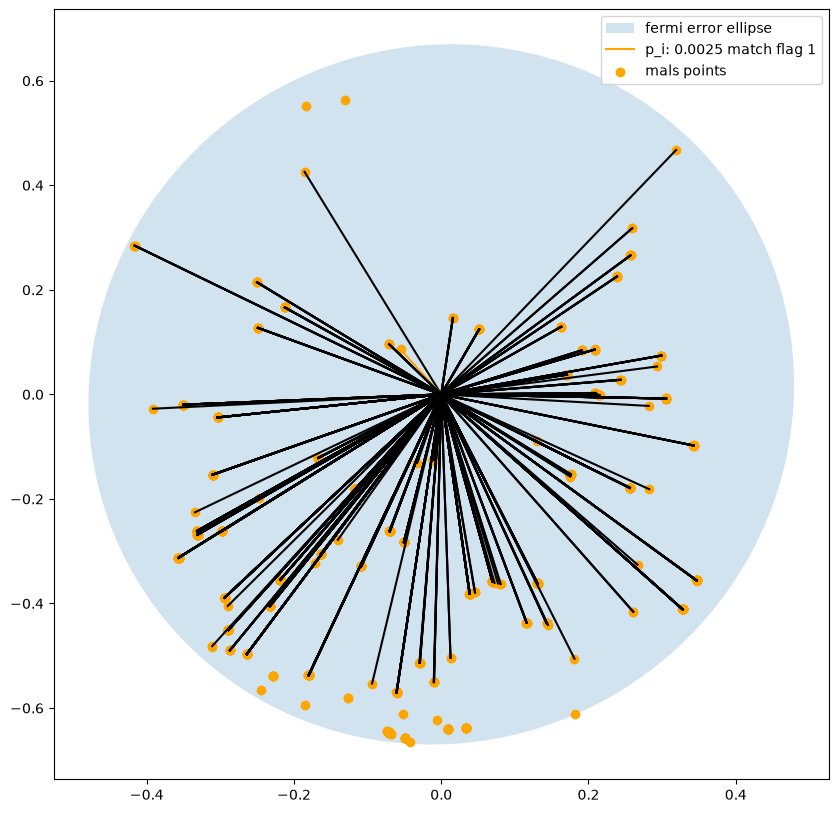

In [ ]:
# position plot of the actual positions 
fig, ax = plt.subplots(figsize=(10,10))
# scatter the fermi ra and dec
# ax.scatter(bay_step_2['FERMI_RAJ2000'], bay_step_2['FERMI_RAJ2000'])
ellipse = patches.Ellipse((0, 0), bay_table['FERMI_Conf_95_SemiMajor'][0]*2, bay_table['FERMI_Conf_95_SemiMinor'][0]*2,
                          angle=angle, alpha=0.2, label='fermi error ellipse')

ax.add_patch(ellipse)
for source in bay_table:
    if source['match_flag'] == 2:
        ax.plot([0, source['ra_diff'] ],[0, source['dec_diff']], color='black')
    elif source['match_flag'] == 1:
        ax.plot([0, source['ra_diff']],[0, source['dec_diff']], color='orange', label=f'p_i: {source['p_i']:.4f} match flag 1')

ax.scatter(bay_table[1:]['ra_diff'], bay_table[1:]['dec_diff'], color ='orange', label='mals points')
ax.legend(loc='best')

plt.savefig('dist_match_4FGL_J0041.3-0048_bay.fits')
# ax.set_xlim(-0.0005,0.0005)
# the highest prob source! 


##### boke plotting

In [314]:
from bokeh.layouts import layout
from bokeh.models import ColumnDataSource, Grid, LinearAxis, Plot
from bokeh.plotting import figure,output_file
from bokeh.io import output_notebook, curdoc, show

from bokeh.layouts import column
from bokeh.models import (ColumnDataSource, DataTable, HoverTool, IntEditor,
                          NumberEditor, NumberFormatter, SelectEditor,
                          StringEditor, StringFormatter, TableColumn)
from bokeh.models import CustomJS, Slider
from bokeh.models import CheckboxGroup, CustomJS

from astropy. table import Table
import pandas
from bokeh.layouts import row
from bokeh.layouts import gridplot
from bokeh.plotting import figure, output_file, show
from bokeh.models import LinearColorMapper, LogTicker, ColorBar
from bokeh.palettes import Viridis256
from bokeh.transform import linear_cmap
from bokeh.models import ColorBar    


# from bokeh.plotting import figure, show
# from bokeh.sampledata.autompg2 import autompg2 as mpg
from bokeh.palettes import Category20


In [297]:
bay_table['FERMI_Conf_95_SemiMajor'] = bay_table['FERMI_Conf_95_SemiMajor']*2
bay_table['FERMI_Conf_95_SemiMinor'] = bay_table['FERMI_Conf_95_SemiMinor']*2

In [298]:
bay_table = bay_table.to_pandas()

In [299]:
all_class_associations = list(set(bay_table[1:]['MALS_L_spw_matches']))
num_list_associations =[]
for assoc in bay_table[1:]['MALS_L_spw_matches']:
    num = all_class_associations.index(assoc)
    num_list_associations.append(num)

In [311]:
bay_table_2['current_alphas'] = len(bay_table_2) * [1]

In [300]:
bay_table_2 = bay_table[1:]

In [301]:
bay_table_2['mals_spw_num'] = num_list_associations

In [302]:
bay_table_2['MALS_L_s_code'] = bay_table_2['MALS_L_s_code'].str.decode('utf-8')

In [308]:
bay_fermi = bay_table[0:1]
bay_fermi['FERMI_Conf_95_PosAng'] = (np.radians(bay_fermi['FERMI_Conf_95_PosAng'].values*u.deg)).value

In [316]:
output_notebook()

source =ColumnDataSource(data=bay_table_2)
fermi_source =ColumnDataSource(data=bay_fermi)

plot = figure(title='Ellipse XXXX')
# color map for the range of values
color_mapper = LinearColorMapper(
    palette=Category20[20], 
    low=min(list(range(len(list(set(source.data['MALS_L_spw_matches'])))))), 
    high=max(list(range(len(list(set(source.data['MALS_L_spw_matches']))))))
)
# 2.create all the other sources in each fermi_ellipse and link them to a source via a name for some tool?
# plot.scatter(marker='star', )
# must plot a color bar as spectral index

mal_points =plot.scatter(x='MALS_L_RAJ2000', y='MALS_L_DECJ200',
                             source=source,
                             color={'field': 'mals_spw_num', 'transform': color_mapper},
                             legend_field='MALS_L_spw_matches',
                             alpha='current_alphas')

fermi_ellipses = plot.ellipse(x='FERMI_RAJ2000', y='FERMI_DECJ200', width='FERMI_Conf_95_SemiMajor',
                              height='FERMI_Conf_95_SemiMinor', angle='FERMI_Conf_95_PosAng',
                             source=fermi_source, alpha =0.2)

# slider for all the years 
# we will have a columndata source for each year
# based on the slider it will show a specific column data source 

# all the possible labels for the data
LABELS = (list(set(source.data['MALS_L_s_code'])))
# Initialize CheckboxGroup
checkbox_group = CheckboxGroup(labels=LABELS, active=list(range(len(LABELS))))
# Pass LABELS to the args dictionary so the CustomJS snippet can read it
callback = CustomJS(args=dict(source=source, LABELS=LABELS), code="""
    const data = source.data;
    // just outputs all the active points 
    const active_indices = cb_obj.active;
    
    //get the indexes for all the points for the active indicies 
    const active_labels = active_indices.map(i => LABELS[i]);
    
    const class2_data = data['MALS_L_s_code'];
    const current_alphas = data['current_alphas'];
    
    //checks the alpha for every point!
    for (let i = 0; i < class2_data.length; i++) {
        // If the label is active, set alpha to 1, else 0
        if (active_labels.includes(class2_data[i])) {
            current_alphas[i] = 1;
        } else {
            current_alphas[i] = 0;
        }
    }
    // Only emit the change once after the loop finishes
    source.change.emit();
""")

checkbox_group.js_on_change('active', callback)


plot.legend.location = "top_right"
plot.legend.title = "CLASS2 Associations"

# tools that let you vary the values for flux ratio, and spectral index 
# must link it to the number of 'matched sources' to show them changes based on certain parameters!

# axis titles
plot.xaxis.axis_label = 'Right Acension RAJ2000'
plot.yaxis.axis_label = 'Declination DEJ2000'

my_layout = row(plot, checkbox_group)
show(my_layout)

Loading BokehJS ...

## PRIOR ADDING 
the prior probability did increase by ~.028 from the previous max of .0025 so I would say alot! why?

In [30]:
bay_table_flux_prior = QTable.read(catalog_fermi_nway+'4FGL_J0041.3-0048_bay_flux_test.fits', format='fits')

In [31]:
bay_table_flux_prior

FERMI_Source_Name,FERMI_DataRelease,FERMI_RAJ2000,FERMI_DECJ2000,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Extended_Source_Name,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_LP_EPeak,FERMI_Unc_LP_EPeak,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_Unc_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_PLEC_EPeak,FERMI_Unc_PLEC_EPeak,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_ASSOC_4FGL,FERMI_ASSOC_FGL,FERMI_ASSOC_FHL,FERMI_ASSOC_GAM1,FERMI_ASSOC_GAM2,FERMI_ASSOC_GAM3,FERMI_TEVCAT_FLAG,FERMI_ASSOC_TEV,FERMI_CLASS1,FERMI_CLASS2,FERMI_ASSOC1,FERMI_ASSOC2,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_RA_Counterpart,FERMI_DEC_Counterpart,FERMI_Unc_Counterpart,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_id_x,FERMI_pointing_name,FERMI_obs_date_u,FERMI_obs_date_l,FERMI_obs_band,FERMI_pbeam_version,FERMI_fluxcal,FERMI_fluxscale,FERMI_spw_id,FERMI_ref_freq,FERMI_maj_restoring_beam,FERMI_min_restoring_beam,FERMI_pa_restoring_beam,FERMI_sigma_1,FERMI_sigma_2,FERMI_sigma_20,FERMI_source_id,FERMI_metadata_id,FERMI_source_name,FERMI_distance_pointing,FERMI_distance_nn,FERMI_s_code,FERMI_n_gauss,FERMI_maxsep_gauss,FERMI_maj,FERMI_maj_e,FERMI_min,FERMI_min_e,FERMI_pa,FERMI_pa_e,FERMI_dc_maj,FERMI_dc_maj_e,FERMI_dc_min,FERMI_dc_min_e,FERMI_dc_pa,FERMI_dc_pa_e,FERMI_ra_mean_e,FERMI_dec_mean_e,FERMI_ra_max,FERMI_ra_max_e,FERMI_dec_max,FERMI_dec_max_e,FERMI_total_flux,FERMI_total_flux_e,FERMI_total_flux_e_fit,FERMI_total_flux_e_sys,FERMI_total_flux_measured,FERMI_total_flux_measured_e,FERMI_peak_flux,FERMI_peak_flux_e,FERMI_isl_total_flux,FERMI_isl_total_flux_e,FERMI_isl_rms,FERMI_isl_mean,FERMI_resid_isl_rms,FERMI_resid_isl_mean,FERMI_flux_correction,FERMI_real_source,FERMI_resolved,FERMI_source_linked,FERMI_id_y,FERMI_spectral_index,FERMI_spectral_index_e,FERMI_spectral_index_spwused,FERMI_spectral_index_spwfit,FERMI_spectral_index_spwfit_e,FERMI_spectral_index_mals_lit,FERMI_spectral_index_mals_lit_e,FERMI_spectral_index_lit,FERMI_FluxRatio,FERMI_spw_matches,FERMI_pos_err,FERMI_ID,MALS_L_Source_Name,MALS_L_DataRelease,MALS_L_RAJ2000,MALS_L_DECJ2000,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Extended_Source_Name,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS_L_SpectrumType,MALS_L_PL_Flux_Density,MALS_L_Unc_PL_Flux_Density,MALS_L_PL_Index,MALS_L_Unc_PL_Index,MALS_L_LP_Flux_Density,MALS_L_Unc_LP_Flux_Density,MALS_L_LP_Index,MALS_L_Unc_LP_Index,MALS_L_LP_beta,MALS_L_Unc_LP_beta,MALS_L_LP_SigCurv,MALS_L_LP_EPeak,MALS_L_Unc_LP_EPeak,MALS_L_PLEC_Flux_Density,MALS_L_Unc_PLEC_Flux_Density,MALS_L_PLEC_IndexS,MALS_L_Unc_PLEC_IndexS,MALS_L_PLEC_ExpfactorS,MALS_L_Unc_PLEC_ExpfactorS,MALS_L_PLEC_Exp_Index,MALS_L_Unc_PLEC_Exp_Index,MALS_L_PLEC_SigCurv,MALS_L_PLEC_EPeak,MALS_L_Unc_PLEC_EPeak,MALS_L_Npred,MALS_L_Flux_Band,MALS_L_Unc_Flux_Band,MALS_L_nuFnu_Band,MALS_L_Sqrt_TS_Band,MALS_L_Variability_Index,MALS_L_Frac_Variability,MALS_L_Unc_Frac_Variability,MALS_L_Signif_Peak,MALS_L_Flux_Peak,MALS_L_Unc_Flux_Peak,MAL

In [4]:
bay_table_flux_prior = QTable.read(catalog_fermi_nway+'4FGL_J0041.3-0048_bay_flux_test.fits', format='fits')

In [5]:
bay_table_flux_prior[bay_table_flux_prior['match_flag']==2]

FERMI_Source_Name,FERMI_DataRelease,FERMI_RAJ2000,FERMI_DECJ2000,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Extended_Source_Name,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_LP_EPeak,FERMI_Unc_LP_EPeak,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_Unc_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_PLEC_EPeak,FERMI_Unc_PLEC_EPeak,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_ASSOC_4FGL,FERMI_ASSOC_FGL,FERMI_ASSOC_FHL,FERMI_ASSOC_GAM1,FERMI_ASSOC_GAM2,FERMI_ASSOC_GAM3,FERMI_TEVCAT_FLAG,FERMI_ASSOC_TEV,FERMI_CLASS1,FERMI_CLASS2,FERMI_ASSOC1,FERMI_ASSOC2,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_RA_Counterpart,FERMI_DEC_Counterpart,FERMI_Unc_Counterpart,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_id_x,FERMI_pointing_name,FERMI_obs_date_u,FERMI_obs_date_l,FERMI_obs_band,FERMI_pbeam_version,FERMI_fluxcal,FERMI_fluxscale,FERMI_spw_id,FERMI_ref_freq,FERMI_maj_restoring_beam,FERMI_min_restoring_beam,FERMI_pa_restoring_beam,FERMI_sigma_1,FERMI_sigma_2,FERMI_sigma_20,FERMI_source_id,FERMI_metadata_id,FERMI_source_name,FERMI_distance_pointing,FERMI_distance_nn,FERMI_s_code,FERMI_n_gauss,FERMI_maxsep_gauss,FERMI_maj,FERMI_maj_e,FERMI_min,FERMI_min_e,FERMI_pa,FERMI_pa_e,FERMI_dc_maj,FERMI_dc_maj_e,FERMI_dc_min,FERMI_dc_min_e,FERMI_dc_pa,FERMI_dc_pa_e,FERMI_ra_mean_e,FERMI_dec_mean_e,FERMI_ra_max,FERMI_ra_max_e,FERMI_dec_max,FERMI_dec_max_e,FERMI_total_flux,FERMI_total_flux_e,FERMI_total_flux_e_fit,FERMI_total_flux_e_sys,FERMI_total_flux_measured,FERMI_total_flux_measured_e,FERMI_peak_flux,FERMI_peak_flux_e,FERMI_isl_total_flux,FERMI_isl_total_flux_e,FERMI_isl_rms,FERMI_isl_mean,FERMI_resid_isl_rms,FERMI_resid_isl_mean,FERMI_flux_correction,FERMI_real_source,FERMI_resolved,FERMI_source_linked,FERMI_id_y,FERMI_spectral_index,FERMI_spectral_index_e,FERMI_spectral_index_spwused,FERMI_spectral_index_spwfit,FERMI_spectral_index_spwfit_e,FERMI_spectral_index_mals_lit,FERMI_spectral_index_mals_lit_e,FERMI_spectral_index_lit,FERMI_FluxRatio,FERMI_spw_matches,FERMI_pos_err,FERMI_ID,MALS_L_Source_Name,MALS_L_DataRelease,MALS_L_RAJ2000,MALS_L_DECJ2000,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Extended_Source_Name,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS_L_SpectrumType,MALS_L_PL_Flux_Density,MALS_L_Unc_PL_Flux_Density,MALS_L_PL_Index,MALS_L_Unc_PL_Index,MALS_L_LP_Flux_Density,MALS_L_Unc_LP_Flux_Density,MALS_L_LP_Index,MALS_L_Unc_LP_Index,MALS_L_LP_beta,MALS_L_Unc_LP_beta,MALS_L_LP_SigCurv,MALS_L_LP_EPeak,MALS_L_Unc_LP_EPeak,MALS_L_PLEC_Flux_Density,MALS_L_Unc_PLEC_Flux_Density,MALS_L_PLEC_IndexS,MALS_L_Unc_PLEC_IndexS,MALS_L_PLEC_ExpfactorS,MALS_L_Unc_PLEC_ExpfactorS,MALS_L_PLEC_Exp_Index,MALS_L_Unc_PLEC_Exp_Index,MALS_L_PLEC_SigCurv,MALS_L_PLEC_EPeak,MALS_L_Unc_PLEC_EPeak,MALS_L_Npred,MALS_L_Flux_Band,MALS_L_Unc_Flux_Band,MALS_L_nuFnu_Band,MALS_L_Sqrt_TS_Band,MALS_L_Variability_Index,MALS_L_Frac_Variability,MALS_L_Unc_Frac_Variability,MALS_L_Signif_Peak,MALS_L_Flux_Peak,MALS_L_Unc_Flux_Peak,MAL

In [6]:
bay_table_flux_prior[bay_table_flux_prior['match_flag']==1]

FERMI_Source_Name,FERMI_DataRelease,FERMI_RAJ2000,FERMI_DECJ2000,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Extended_Source_Name,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_LP_EPeak,FERMI_Unc_LP_EPeak,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_Unc_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_PLEC_EPeak,FERMI_Unc_PLEC_EPeak,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_ASSOC_4FGL,FERMI_ASSOC_FGL,FERMI_ASSOC_FHL,FERMI_ASSOC_GAM1,FERMI_ASSOC_GAM2,FERMI_ASSOC_GAM3,FERMI_TEVCAT_FLAG,FERMI_ASSOC_TEV,FERMI_CLASS1,FERMI_CLASS2,FERMI_ASSOC1,FERMI_ASSOC2,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_RA_Counterpart,FERMI_DEC_Counterpart,FERMI_Unc_Counterpart,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_id_x,FERMI_pointing_name,FERMI_obs_date_u,FERMI_obs_date_l,FERMI_obs_band,FERMI_pbeam_version,FERMI_fluxcal,FERMI_fluxscale,FERMI_spw_id,FERMI_ref_freq,FERMI_maj_restoring_beam,FERMI_min_restoring_beam,FERMI_pa_restoring_beam,FERMI_sigma_1,FERMI_sigma_2,FERMI_sigma_20,FERMI_source_id,FERMI_metadata_id,FERMI_source_name,FERMI_distance_pointing,FERMI_distance_nn,FERMI_s_code,FERMI_n_gauss,FERMI_maxsep_gauss,FERMI_maj,FERMI_maj_e,FERMI_min,FERMI_min_e,FERMI_pa,FERMI_pa_e,FERMI_dc_maj,FERMI_dc_maj_e,FERMI_dc_min,FERMI_dc_min_e,FERMI_dc_pa,FERMI_dc_pa_e,FERMI_ra_mean_e,FERMI_dec_mean_e,FERMI_ra_max,FERMI_ra_max_e,FERMI_dec_max,FERMI_dec_max_e,FERMI_total_flux,FERMI_total_flux_e,FERMI_total_flux_e_fit,FERMI_total_flux_e_sys,FERMI_total_flux_measured,FERMI_total_flux_measured_e,FERMI_peak_flux,FERMI_peak_flux_e,FERMI_isl_total_flux,FERMI_isl_total_flux_e,FERMI_isl_rms,FERMI_isl_mean,FERMI_resid_isl_rms,FERMI_resid_isl_mean,FERMI_flux_correction,FERMI_real_source,FERMI_resolved,FERMI_source_linked,FERMI_id_y,FERMI_spectral_index,FERMI_spectral_index_e,FERMI_spectral_index_spwused,FERMI_spectral_index_spwfit,FERMI_spectral_index_spwfit_e,FERMI_spectral_index_mals_lit,FERMI_spectral_index_mals_lit_e,FERMI_spectral_index_lit,FERMI_FluxRatio,FERMI_spw_matches,FERMI_pos_err,FERMI_ID,MALS_L_Source_Name,MALS_L_DataRelease,MALS_L_RAJ2000,MALS_L_DECJ2000,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Extended_Source_Name,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS_L_SpectrumType,MALS_L_PL_Flux_Density,MALS_L_Unc_PL_Flux_Density,MALS_L_PL_Index,MALS_L_Unc_PL_Index,MALS_L_LP_Flux_Density,MALS_L_Unc_LP_Flux_Density,MALS_L_LP_Index,MALS_L_Unc_LP_Index,MALS_L_LP_beta,MALS_L_Unc_LP_beta,MALS_L_LP_SigCurv,MALS_L_LP_EPeak,MALS_L_Unc_LP_EPeak,MALS_L_PLEC_Flux_Density,MALS_L_Unc_PLEC_Flux_Density,MALS_L_PLEC_IndexS,MALS_L_Unc_PLEC_IndexS,MALS_L_PLEC_ExpfactorS,MALS_L_Unc_PLEC_ExpfactorS,MALS_L_PLEC_Exp_Index,MALS_L_Unc_PLEC_Exp_Index,MALS_L_PLEC_SigCurv,MALS_L_PLEC_EPeak,MALS_L_Unc_PLEC_EPeak,MALS_L_Npred,MALS_L_Flux_Band,MALS_L_Unc_Flux_Band,MALS_L_nuFnu_Band,MALS_L_Sqrt_TS_Band,MALS_L_Variability_Index,MALS_L_Frac_Variability,MALS_L_Unc_Frac_Variability,MALS_L_Signif_Peak,MALS_L_Flux_Peak,MALS_L_Unc_Flux_Peak,MAL

In [8]:
bay_table_flux_prior_ellipse = bay_table_flux_prior[bay_table_flux_prior['match_flag'] ==1]
index_max_prob = np.argmax(bay_table_flux_prior_ellipse['p_i'])
bay_table_flux_prior_ellipse = bay_table_flux_prior_ellipse[index_max_prob]

In [10]:
bay_table_flux_prior_ellipse

FERMI_Source_Name,FERMI_DataRelease,FERMI_RAJ2000,FERMI_DECJ2000,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Extended_Source_Name,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_LP_EPeak,FERMI_Unc_LP_EPeak,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_Unc_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_PLEC_EPeak,FERMI_Unc_PLEC_EPeak,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_ASSOC_4FGL,FERMI_ASSOC_FGL,FERMI_ASSOC_FHL,FERMI_ASSOC_GAM1,FERMI_ASSOC_GAM2,FERMI_ASSOC_GAM3,FERMI_TEVCAT_FLAG,FERMI_ASSOC_TEV,FERMI_CLASS1,FERMI_CLASS2,FERMI_ASSOC1,FERMI_ASSOC2,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_RA_Counterpart,FERMI_DEC_Counterpart,FERMI_Unc_Counterpart,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_id_x,FERMI_pointing_name,FERMI_obs_date_u,FERMI_obs_date_l,FERMI_obs_band,FERMI_pbeam_version,FERMI_fluxcal,FERMI_fluxscale,FERMI_spw_id,FERMI_ref_freq,FERMI_maj_restoring_beam,FERMI_min_restoring_beam,FERMI_pa_restoring_beam,FERMI_sigma_1,FERMI_sigma_2,FERMI_sigma_20,FERMI_source_id,FERMI_metadata_id,FERMI_source_name,FERMI_distance_pointing,FERMI_distance_nn,FERMI_s_code,FERMI_n_gauss,FERMI_maxsep_gauss,FERMI_maj,FERMI_maj_e,FERMI_min,FERMI_min_e,FERMI_pa,FERMI_pa_e,FERMI_dc_maj,FERMI_dc_maj_e,FERMI_dc_min,FERMI_dc_min_e,FERMI_dc_pa,FERMI_dc_pa_e,FERMI_ra_mean_e,FERMI_dec_mean_e,FERMI_ra_max,FERMI_ra_max_e,FERMI_dec_max,FERMI_dec_max_e,FERMI_total_flux,FERMI_total_flux_e,FERMI_total_flux_e_fit,FERMI_total_flux_e_sys,FERMI_total_flux_measured,FERMI_total_flux_measured_e,FERMI_peak_flux,FERMI_peak_flux_e,FERMI_isl_total_flux,FERMI_isl_total_flux_e,FERMI_isl_rms,FERMI_isl_mean,FERMI_resid_isl_rms,FERMI_resid_isl_mean,FERMI_flux_correction,FERMI_real_source,FERMI_resolved,FERMI_source_linked,FERMI_id_y,FERMI_spectral_index,FERMI_spectral_index_e,FERMI_spectral_index_spwused,FERMI_spectral_index_spwfit,FERMI_spectral_index_spwfit_e,FERMI_spectral_index_mals_lit,FERMI_spectral_index_mals_lit_e,FERMI_spectral_index_lit,FERMI_FluxRatio,FERMI_spw_matches,FERMI_pos_err,FERMI_ID,MALS_L_Source_Name,MALS_L_DataRelease,MALS_L_RAJ2000,MALS_L_DECJ2000,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Extended_Source_Name,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS_L_SpectrumType,MALS_L_PL_Flux_Density,MALS_L_Unc_PL_Flux_Density,MALS_L_PL_Index,MALS_L_Unc_PL_Index,MALS_L_LP_Flux_Density,MALS_L_Unc_LP_Flux_Density,MALS_L_LP_Index,MALS_L_Unc_LP_Index,MALS_L_LP_beta,MALS_L_Unc_LP_beta,MALS_L_LP_SigCurv,MALS_L_LP_EPeak,MALS_L_Unc_LP_EPeak,MALS_L_PLEC_Flux_Density,MALS_L_Unc_PLEC_Flux_Density,MALS_L_PLEC_IndexS,MALS_L_Unc_PLEC_IndexS,MALS_L_PLEC_ExpfactorS,MALS_L_Unc_PLEC_ExpfactorS,MALS_L_PLEC_Exp_Index,MALS_L_Unc_PLEC_Exp_Index,MALS_L_PLEC_SigCurv,MALS_L_PLEC_EPeak,MALS_L_Unc_PLEC_EPeak,MALS_L_Npred,MALS_L_Flux_Band,MALS_L_Unc_Flux_Band,MALS_L_nuFnu_Band,MALS_L_Sqrt_TS_Band,MALS_L_Variability_Index,MALS_L_Frac_Variability,MALS_L_Unc_Frac_Variability,MALS_L_Signif_Peak,MALS_L_Flux_Peak,MALS_L_Unc_Flux_Peak,MAL

In [15]:
angle= bay_table_flux_prior_ellipse['FERMI_Conf_95_PosAng']

Text(0.5, 1.0, 'Ellipse: 4FGL J0041.3-0048 MALS matching w/flux prior')

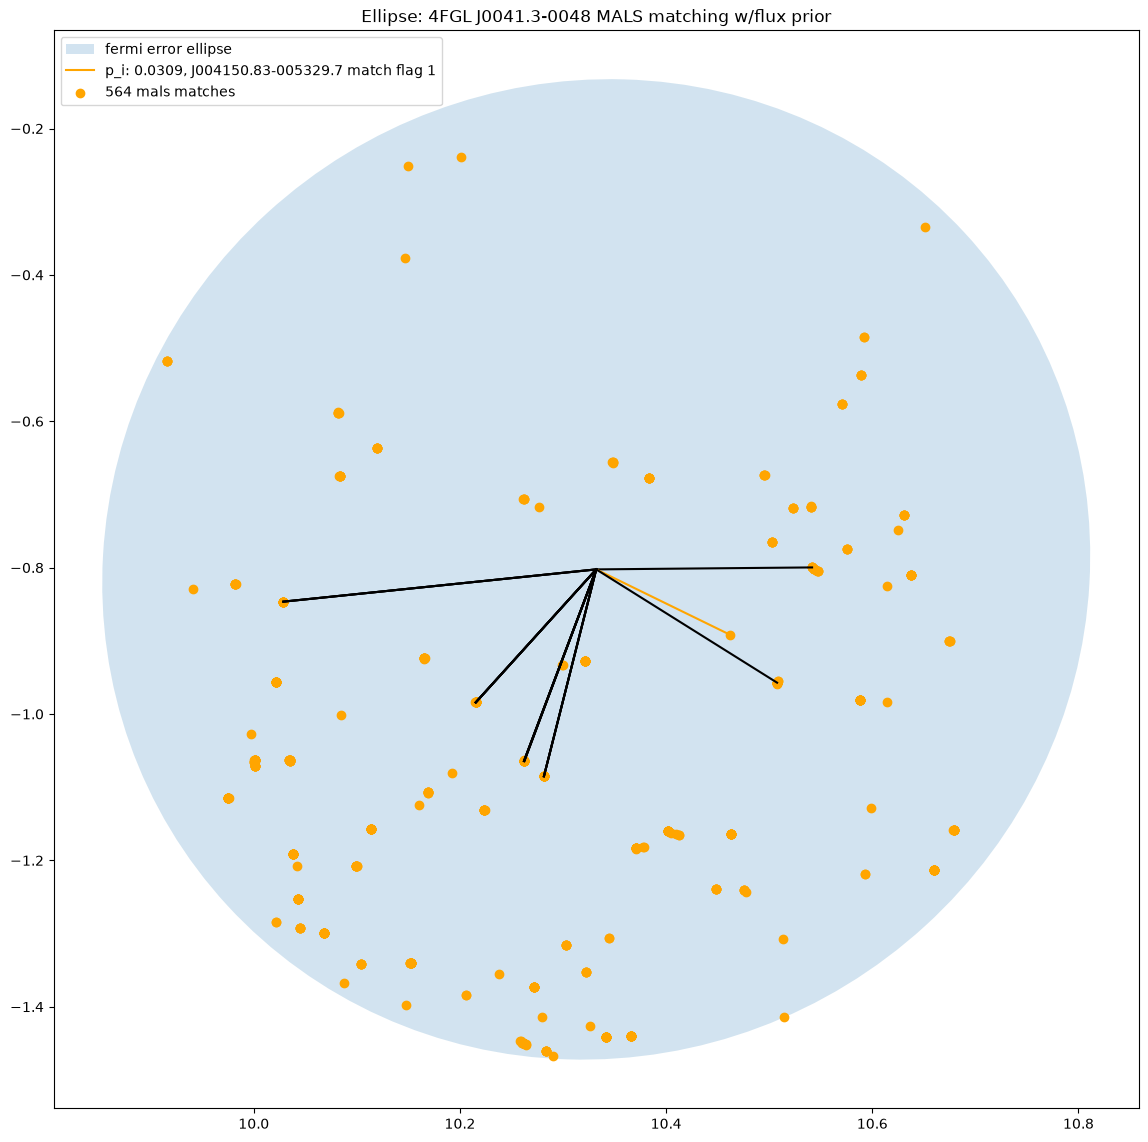

In [16]:
# dont have to call the fermi ra and j like this since all the sources wil have same but it doesnt matter

# position plot of the actual positions 
fig, ax = plt.subplots(figsize=(14,14))
# scatter the fermi ra and dec
# ax.scatter(bay_step_2['FERMI_RAJ2000'], bay_step_2['FERMI_RAJ2000'])
ellipse = patches.Ellipse((bay_table_flux_prior_ellipse['FERMI_RAJ2000'], bay_table_flux_prior_ellipse['FERMI_DECJ2000']),
                          bay_table_flux_prior_ellipse['FERMI_Conf_95_SemiMajor']*2, bay_table_flux_prior_ellipse['FERMI_Conf_95_SemiMinor']*2,
                          angle=angle, alpha=0.2, label='fermi error ellipse')

ax.add_patch(ellipse)
for source in bay_table_flux_prior:
    if source['match_flag'] == 1:
        ax.plot([source['FERMI_RAJ2000'], source['MALS_L_RAJ2000']],[source['FERMI_DECJ2000'], source['MALS_L_DECJ2000']],
                color='orange', label=f'p_i: {source['p_i']:.4f}, {source['MALS_L_spw_matches']} match flag 1')
    elif source['match_flag'] == 2:
        ax.plot([source['FERMI_RAJ2000'], source['MALS_L_RAJ2000'] ],[source['FERMI_DECJ2000'], source['MALS_L_DECJ2000']], color='black')

ax.scatter(bay_table_flux_prior[1:]['MALS_L_RAJ2000'], bay_table_flux_prior[1:]['MALS_L_DECJ2000'],
           color ='orange', label=f'{len(bay_table_flux_prior[1:])} mals matches')
ax.legend(loc='best')
plt.title(f'Ellipse: {bay_table_flux_prior[0]['FERMI_Source_Name']} MALS matching w/flux prior')
# plt.savefig('dist_match_4FGL_J0041.3-0048_bay.png')
# the highest prob source! 


In [ ]:
#### Offset w/flux prior

In [27]:
bay_table_flux_prior_fake

FAKE_FERMI_Source_Name,FAKE_FERMI_DataRelease,FAKE_FERMI_RAJ2000,FAKE_FERMI_DECJ2000,FAKE_FERMI_GLON,FAKE_FERMI_GLAT,FAKE_FERMI_Conf_68_SemiMajor,FAKE_FERMI_Conf_68_SemiMinor,FAKE_FERMI_Conf_68_PosAng,FAKE_FERMI_Conf_95_SemiMajor,FAKE_FERMI_Conf_95_SemiMinor,FAKE_FERMI_Conf_95_PosAng,FAKE_FERMI_ROI_num,FAKE_FERMI_Extended_Source_Name,FAKE_FERMI_Signif_Avg,FAKE_FERMI_Pivot_Energy,FAKE_FERMI_Flux1000,FAKE_FERMI_Unc_Flux1000,FAKE_FERMI_Energy_Flux100,FAKE_FERMI_Unc_Energy_Flux100,FAKE_FERMI_SpectrumType,FAKE_FERMI_PL_Flux_Density,FAKE_FERMI_Unc_PL_Flux_Density,FAKE_FERMI_PL_Index,FAKE_FERMI_Unc_PL_Index,FAKE_FERMI_LP_Flux_Density,FAKE_FERMI_Unc_LP_Flux_Density,FAKE_FERMI_LP_Index,FAKE_FERMI_Unc_LP_Index,FAKE_FERMI_LP_beta,FAKE_FERMI_Unc_LP_beta,FAKE_FERMI_LP_SigCurv,FAKE_FERMI_LP_EPeak,FAKE_FERMI_Unc_LP_EPeak,FAKE_FERMI_PLEC_Flux_Density,FAKE_FERMI_Unc_PLEC_Flux_Density,FAKE_FERMI_PLEC_IndexS,FAKE_FERMI_Unc_PLEC_IndexS,FAKE_FERMI_PLEC_ExpfactorS,FAKE_FERMI_Unc_PLEC_ExpfactorS,FAKE_FERMI_PLEC_Exp_Index,FAKE_FERMI_Unc_PLEC_Exp_Index,FAKE_FERMI_PLEC_SigCurv,FAKE_FERMI_PLEC_EPeak,FAKE_FERMI_Unc_PLEC_EPeak,FAKE_FERMI_Npred,FAKE_FERMI_Flux_Band,FAKE_FERMI_Unc_Flux_Band,FAKE_FERMI_nuFnu_Band,FAKE_FERMI_Sqrt_TS_Band,FAKE_FERMI_Variability_Index,FAKE_FERMI_Frac_Variability,FAKE_FERMI_Unc_Frac_Variability,FAKE_FERMI_Signif_Peak,FAKE_FERMI_Flux_Peak,FAKE_FERMI_Unc_Flux_Peak,FAKE_FERMI_Time_Peak,FAKE_FERMI_Peak_Interval,FAKE_FERMI_Flux_History,FAKE_FERMI_Unc_Flux_History,FAKE_FERMI_Sqrt_TS_History,FAKE_FERMI_ASSOC_4FGL,FAKE_FERMI_ASSOC_FGL,FAKE_FERMI_ASSOC_FHL,FAKE_FERMI_ASSOC_GAM1,FAKE_FERMI_ASSOC_GAM2,FAKE_FERMI_ASSOC_GAM3,FAKE_FERMI_TEVCAT_FLAG,FAKE_FERMI_ASSOC_TEV,FAKE_FERMI_CLASS1,FAKE_FERMI_CLASS2,FAKE_FERMI_ASSOC1,FAKE_FERMI_ASSOC2,FAKE_FERMI_ASSOC_PROB_BAY,FAKE_FERMI_ASSOC_PROB_LR,FAKE_FERMI_RA_Counterpart,FAKE_FERMI_DEC_Counterpart,FAKE_FERMI_Unc_Counterpart,FAKE_FERMI_Flags,FAKE_FERMI_Indexes,FAKE_FERMI_catalog_names,FAKE_FERMI_id_x,FAKE_FERMI_pointing_name,FAKE_FERMI_obs_date_u,FAKE_FERMI_obs_date_l,FAKE_FERMI_obs_band,FAKE_FERMI_pbeam_version,FAKE_FERMI_fluxcal,FAKE_FERMI_fluxscale,FAKE_FERMI_spw_id,FAKE_FERMI_ref_freq,FAKE_FERMI_maj_restoring_beam,FAKE_FERMI_min_restoring_beam,FAKE_FERMI_pa_restoring_beam,FAKE_FERMI_sigma_1,FAKE_FERMI_sigma_2,FAKE_FERMI_sigma_20,FAKE_FERMI_source_id,FAKE_FERMI_metadata_id,FAKE_FERMI_source_name,FAKE_FERMI_distance_pointing,FAKE_FERMI_distance_nn,FAKE_FERMI_s_code,FAKE_FERMI_n_gauss,FAKE_FERMI_maxsep_gauss,FAKE_FERMI_maj,FAKE_FERMI_maj_e,FAKE_FERMI_min,FAKE_FERMI_min_e,FAKE_FERMI_pa,FAKE_FERMI_pa_e,FAKE_FERMI_dc_maj,FAKE_FERMI_dc_maj_e,FAKE_FERMI_dc_min,FAKE_FERMI_dc_min_e,FAKE_FERMI_dc_pa,FAKE_FERMI_dc_pa_e,FAKE_FERMI_ra_mean_e,FAKE_FERMI_dec_mean_e,FAKE_FERMI_ra_max,FAKE_FERMI_ra_max_e,FAKE_FERMI_dec_max,FAKE_FERMI_dec_max_e,FAKE_FERMI_total_flux,FAKE_FERMI_total_flux_e,FAKE_FERMI_total_flux_e_fit,FAKE_FERMI_total_flux_e_sys,FAKE_FERMI_total_flux_measured,FAKE_FERMI_total_flux_measured_e,FAKE_FERMI_peak_flux,FAKE_FERMI_peak_flux_e,FAKE_FERMI_isl_total_flux,FAKE_FERMI_isl_total_flux_e,FAKE_FERMI_isl_rms,FAKE_FERMI_isl_mean,FAKE_FERMI_resid_isl_rms,FAKE_FERMI_resid_isl_mean,FAKE_FERMI_flux_correction,FAKE_FERMI_real_source,FAKE_FERMI_resolved,FAKE_FERMI_source_linked,FAKE_FERMI_id_y,FAKE_FERMI_spectral_index,FAKE_FERMI_spectral_index_e,FAKE_FERMI_spectral_index_spwused,FAKE_FERMI_spectral_index_spwfit,FAKE_FERMI_spectral_index_spwfit_e,FAKE_FERMI_spectral_index_mals_lit,FAKE_FERMI_spectral_index_mals_lit_e,FAKE_FERMI_spectral_index_lit,FAKE_FERMI_FluxRatio,FAKE_FERMI_spw_matches,FAKE_FERMI_pos_err,MALS_L_Source_Name,MALS_L_DataRelease,MALS_L_RAJ2000,MALS_L_DECJ2000,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Extended_Source_Name,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS

In [23]:
bay_table_flux_prior_fake

FAKE_FERMI_Source_Name,FAKE_FERMI_DataRelease,FAKE_FERMI_RAJ2000,FAKE_FERMI_DECJ2000,FAKE_FERMI_GLON,FAKE_FERMI_GLAT,FAKE_FERMI_Conf_68_SemiMajor,FAKE_FERMI_Conf_68_SemiMinor,FAKE_FERMI_Conf_68_PosAng,FAKE_FERMI_Conf_95_SemiMajor,FAKE_FERMI_Conf_95_SemiMinor,FAKE_FERMI_Conf_95_PosAng,FAKE_FERMI_ROI_num,FAKE_FERMI_Extended_Source_Name,FAKE_FERMI_Signif_Avg,FAKE_FERMI_Pivot_Energy,FAKE_FERMI_Flux1000,FAKE_FERMI_Unc_Flux1000,FAKE_FERMI_Energy_Flux100,FAKE_FERMI_Unc_Energy_Flux100,FAKE_FERMI_SpectrumType,FAKE_FERMI_PL_Flux_Density,FAKE_FERMI_Unc_PL_Flux_Density,FAKE_FERMI_PL_Index,FAKE_FERMI_Unc_PL_Index,FAKE_FERMI_LP_Flux_Density,FAKE_FERMI_Unc_LP_Flux_Density,FAKE_FERMI_LP_Index,FAKE_FERMI_Unc_LP_Index,FAKE_FERMI_LP_beta,FAKE_FERMI_Unc_LP_beta,FAKE_FERMI_LP_SigCurv,FAKE_FERMI_LP_EPeak,FAKE_FERMI_Unc_LP_EPeak,FAKE_FERMI_PLEC_Flux_Density,FAKE_FERMI_Unc_PLEC_Flux_Density,FAKE_FERMI_PLEC_IndexS,FAKE_FERMI_Unc_PLEC_IndexS,FAKE_FERMI_PLEC_ExpfactorS,FAKE_FERMI_Unc_PLEC_ExpfactorS,FAKE_FERMI_PLEC_Exp_Index,FAKE_FERMI_Unc_PLEC_Exp_Index,FAKE_FERMI_PLEC_SigCurv,FAKE_FERMI_PLEC_EPeak,FAKE_FERMI_Unc_PLEC_EPeak,FAKE_FERMI_Npred,FAKE_FERMI_Flux_Band,FAKE_FERMI_Unc_Flux_Band,FAKE_FERMI_nuFnu_Band,FAKE_FERMI_Sqrt_TS_Band,FAKE_FERMI_Variability_Index,FAKE_FERMI_Frac_Variability,FAKE_FERMI_Unc_Frac_Variability,FAKE_FERMI_Signif_Peak,FAKE_FERMI_Flux_Peak,FAKE_FERMI_Unc_Flux_Peak,FAKE_FERMI_Time_Peak,FAKE_FERMI_Peak_Interval,FAKE_FERMI_Flux_History,FAKE_FERMI_Unc_Flux_History,FAKE_FERMI_Sqrt_TS_History,FAKE_FERMI_ASSOC_4FGL,FAKE_FERMI_ASSOC_FGL,FAKE_FERMI_ASSOC_FHL,FAKE_FERMI_ASSOC_GAM1,FAKE_FERMI_ASSOC_GAM2,FAKE_FERMI_ASSOC_GAM3,FAKE_FERMI_TEVCAT_FLAG,FAKE_FERMI_ASSOC_TEV,FAKE_FERMI_CLASS1,FAKE_FERMI_CLASS2,FAKE_FERMI_ASSOC1,FAKE_FERMI_ASSOC2,FAKE_FERMI_ASSOC_PROB_BAY,FAKE_FERMI_ASSOC_PROB_LR,FAKE_FERMI_RA_Counterpart,FAKE_FERMI_DEC_Counterpart,FAKE_FERMI_Unc_Counterpart,FAKE_FERMI_Flags,FAKE_FERMI_Indexes,FAKE_FERMI_catalog_names,FAKE_FERMI_id_x,FAKE_FERMI_pointing_name,FAKE_FERMI_obs_date_u,FAKE_FERMI_obs_date_l,FAKE_FERMI_obs_band,FAKE_FERMI_pbeam_version,FAKE_FERMI_fluxcal,FAKE_FERMI_fluxscale,FAKE_FERMI_spw_id,FAKE_FERMI_ref_freq,FAKE_FERMI_maj_restoring_beam,FAKE_FERMI_min_restoring_beam,FAKE_FERMI_pa_restoring_beam,FAKE_FERMI_sigma_1,FAKE_FERMI_sigma_2,FAKE_FERMI_sigma_20,FAKE_FERMI_source_id,FAKE_FERMI_metadata_id,FAKE_FERMI_source_name,FAKE_FERMI_distance_pointing,FAKE_FERMI_distance_nn,FAKE_FERMI_s_code,FAKE_FERMI_n_gauss,FAKE_FERMI_maxsep_gauss,FAKE_FERMI_maj,FAKE_FERMI_maj_e,FAKE_FERMI_min,FAKE_FERMI_min_e,FAKE_FERMI_pa,FAKE_FERMI_pa_e,FAKE_FERMI_dc_maj,FAKE_FERMI_dc_maj_e,FAKE_FERMI_dc_min,FAKE_FERMI_dc_min_e,FAKE_FERMI_dc_pa,FAKE_FERMI_dc_pa_e,FAKE_FERMI_ra_mean_e,FAKE_FERMI_dec_mean_e,FAKE_FERMI_ra_max,FAKE_FERMI_ra_max_e,FAKE_FERMI_dec_max,FAKE_FERMI_dec_max_e,FAKE_FERMI_total_flux,FAKE_FERMI_total_flux_e,FAKE_FERMI_total_flux_e_fit,FAKE_FERMI_total_flux_e_sys,FAKE_FERMI_total_flux_measured,FAKE_FERMI_total_flux_measured_e,FAKE_FERMI_peak_flux,FAKE_FERMI_peak_flux_e,FAKE_FERMI_isl_total_flux,FAKE_FERMI_isl_total_flux_e,FAKE_FERMI_isl_rms,FAKE_FERMI_isl_mean,FAKE_FERMI_resid_isl_rms,FAKE_FERMI_resid_isl_mean,FAKE_FERMI_flux_correction,FAKE_FERMI_real_source,FAKE_FERMI_resolved,FAKE_FERMI_source_linked,FAKE_FERMI_id_y,FAKE_FERMI_spectral_index,FAKE_FERMI_spectral_index_e,FAKE_FERMI_spectral_index_spwused,FAKE_FERMI_spectral_index_spwfit,FAKE_FERMI_spectral_index_spwfit_e,FAKE_FERMI_spectral_index_mals_lit,FAKE_FERMI_spectral_index_mals_lit_e,FAKE_FERMI_spectral_index_lit,FAKE_FERMI_FluxRatio,FAKE_FERMI_spw_matches,FAKE_FERMI_pos_err,MALS_L_Source_Name,MALS_L_DataRelease,MALS_L_RAJ2000,MALS_L_DECJ2000,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Extended_Source_Name,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS

In [26]:
bay_table_flux_prior_fake = QTable.read(catalog_fermi_nway+'4FGL_J0041.3-0048_bay_flux_test-fake.fits', format='fits') 
bay_table_flux_prior_ellipse_fake = bay_table_flux_prior_fake[bay_table_flux_prior_fake['match_flag'] ==1]
index_max_prob = np.argmax(bay_table_flux_prior_ellipse_fake['p_i'])
bay_table_flux_prior_ellipse_fake = bay_table_flux_prior_ellipse_fake[index_max_prob]
angle= bay_table_flux_prior_ellipse_fake['FAKE_FERMI_Conf_95_PosAng']


Text(0.5, 1.0, 'Ellipse: 4FGL J0041.3-0048 MALS matching w/flux prior')

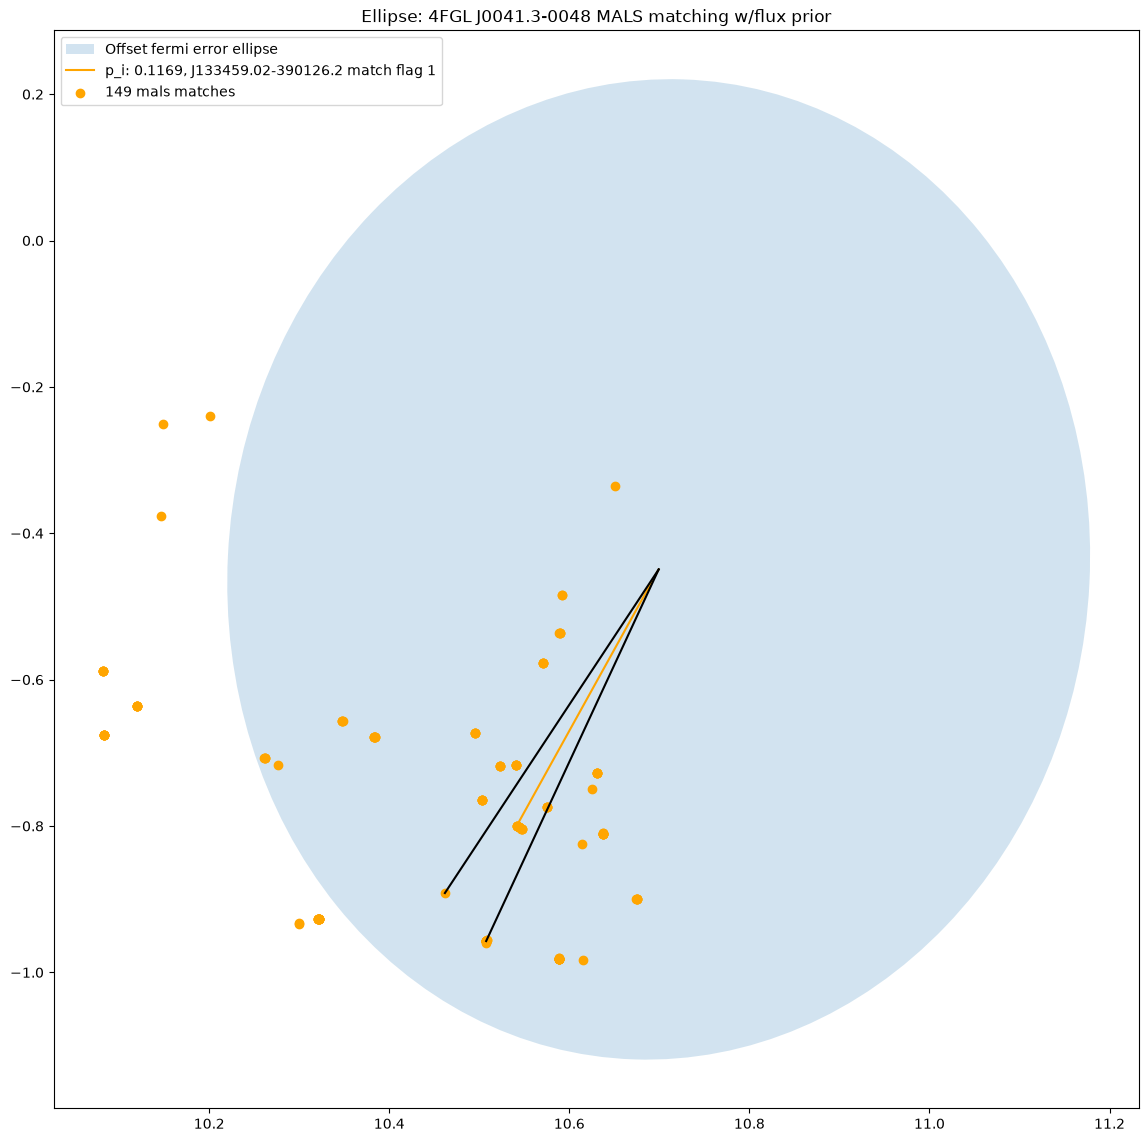

In [29]:
# dont have to call the fermi ra and j like this since all the sources wil have same but it doesnt matter

# position plot of the actual positions 
fig, ax = plt.subplots(figsize=(14,14))
# scatter the fermi ra and dec
# ax.scatter(bay_step_2['FERMI_RAJ2000'], bay_step_2['FERMI_RAJ2000'])
ellipse = patches.Ellipse((bay_table_flux_prior_ellipse_fake['FAKE_FERMI_RAJ2000'], bay_table_flux_prior_ellipse_fake['FAKE_FERMI_DECJ2000']),
                          bay_table_flux_prior_ellipse_fake['FAKE_FERMI_Conf_95_SemiMajor']*2, bay_table_flux_prior_ellipse_fake['FAKE_FERMI_Conf_95_SemiMinor']*2,
                          angle=angle, alpha=0.2, label='Offset fermi error ellipse')

ax.add_patch(ellipse)
for source in bay_table_flux_prior_fake:
    if source['match_flag'] == 1:
        ax.plot([source['FAKE_FERMI_RAJ2000'], source['MALS_L_RAJ2000']],[source['FAKE_FERMI_DECJ2000'], source['MALS_L_DECJ2000']],
                color='orange', label=f'p_i: {source['p_i']:.4f}, {source['MALS_L_spw_matches']} match flag 1')
    elif source['match_flag'] == 2:
        ax.plot([source['FAKE_FERMI_RAJ2000'], source['MALS_L_RAJ2000'] ],[source['FAKE_FERMI_DECJ2000'], source['MALS_L_DECJ2000']], color='black')

ax.scatter(bay_table_flux_prior_fake[1:]['MALS_L_RAJ2000'], bay_table_flux_prior_fake[1:]['MALS_L_DECJ2000'],
           color ='orange', label=f'{len(bay_table_flux_prior_fake[1:])} mals matches')
ax.legend(loc='best')
plt.title(f'Ellipse: {bay_table_flux_prior_fake[0]['FAKE_FERMI_Source_Name']} MALS matching w/flux prior')
# plt.savefig('dist_match_4FGL_J0041.3-0048_bay.png')
# the highest prob source! 


### VIZIER CALL ADDING SOURCES

In [4]:
catalog_fermi_nway_send = '/Users/mario/Coding/nrao_reu_research/socorro/USSCataloging/reduced_catalogs/send_test/'

In [6]:
bay_table_gaia_distance_only = QTable.read(catalog_fermi_nway_send+'4FGL_J0041.3-0048_GM_distance.fits', format='fits')

In [145]:
bay_table_gaia_distance_only['p_absolute'] = bay_table_gaia_distance_only['p_i'] * bay_table_gaia_distance_only['p_any']

In [8]:
bay_table_gaia_distance_only[bay_table_gaia_distance_only['match_flag'] == 2]

FERMI_Source_Name,FERMI_DataRelease,FERMI_RA,FERMI_DEC,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_LP_EPeak,FERMI_Unc_LP_EPeak,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_Unc_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_PLEC_EPeak,FERMI_Unc_PLEC_EPeak,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_TEVCAT_FLAG,FERMI_CLASS1,FERMI_CLASS2,FERMI_ASSOC1,FERMI_ASSOC2,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_RA_Counterpart,FERMI_DEC_Counterpart,FERMI_Unc_Counterpart,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_id_x,FERMI_pbeam_version,FERMI_ref_freq,FERMI_maj_restoring_beam,FERMI_min_restoring_beam,FERMI_pa_restoring_beam,FERMI_sigma_1,FERMI_sigma_2,FERMI_sigma_20,FERMI_source_id,FERMI_metadata_id,FERMI_distance_pointing,FERMI_distance_nn,FERMI_s_code,FERMI_n_gauss,FERMI_maxsep_gauss,FERMI_maj,FERMI_maj_e,FERMI_min,FERMI_min_e,FERMI_pa,FERMI_pa_e,FERMI_dc_maj,FERMI_dc_maj_e,FERMI_dc_min,FERMI_dc_min_e,FERMI_dc_pa,FERMI_dc_pa_e,FERMI_ra_mean_e,FERMI_dec_mean_e,FERMI_ra_max,FERMI_ra_max_e,FERMI_dec_max,FERMI_dec_max_e,FERMI_total_flux,FERMI_total_flux_e,FERMI_total_flux_e_fit,FERMI_total_flux_e_sys,FERMI_total_flux_measured,FERMI_total_flux_measured_e,FERMI_peak_flux,FERMI_peak_flux_e,FERMI_isl_total_flux,FERMI_isl_total_flux_e,FERMI_isl_rms,FERMI_isl_mean,FERMI_resid_isl_rms,FERMI_resid_isl_mean,FERMI_flux_correction,FERMI_id_y,FERMI_FluxRatio,FERMI_pos_err,FERMI_ID,MALS_L_DataRelease,MALS_L_RA,MALS_L_DEC,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS_L_PL_Flux_Density,MALS_L_Unc_PL_Flux_Density,MALS_L_PL_Index,MALS_L_Unc_PL_Index,MALS_L_LP_Flux_Density,MALS_L_Unc_LP_Flux_Density,MALS_L_LP_Index,MALS_L_Unc_LP_Index,MALS_L_LP_beta,MALS_L_Unc_LP_beta,MALS_L_LP_SigCurv,MALS_L_LP_EPeak,MALS_L_Unc_LP_EPeak,MALS_L_PLEC_Flux_Density,MALS_L_Unc_PLEC_Flux_Density,MALS_L_PLEC_IndexS,MALS_L_Unc_PLEC_IndexS,MALS_L_PLEC_ExpfactorS,MALS_L_Unc_PLEC_ExpfactorS,MALS_L_PLEC_Exp_Index,MALS_L_Unc_PLEC_Exp_Index,MALS_L_PLEC_SigCurv,MALS_L_PLEC_EPeak,MALS_L_Unc_PLEC_EPeak,MALS_L_Npred,MALS_L_Flux_Band,MALS_L_Unc_Flux_Band,MALS_L_nuFnu_Band,MALS_L_Sqrt_TS_Band,MALS_L_Variability_Index,MALS_L_Frac_Variability,MALS_L_Unc_Frac_Variability,MALS_L_Signif_Peak,MALS_L_Flux_Peak,MALS_L_Unc_Flux_Peak,MALS_L_Time_Peak,MALS_L_Peak_Interval,MALS_L_Flux_History,MALS_L_Unc_Flux_History,MALS_L_Sqrt_TS_History,MALS_L_ASSOC_PROB_BAY,MALS_L_ASSOC_PROB_LR,MALS_L_RA_Counterpart,MALS_L_DEC_Counterpart,MALS_L_Unc_Counterpart,MALS_L_Flags,MALS_L_Indexes,MALS_L_catalog_names,MALS_L_id_x,MALS_L_pointing_name,MALS_L_obs_date_l,MALS_L_obs_band,MALS_L_pbeam_version,MALS_L_fluxcal,MALS_L_fluxscale,MALS_L_spw_id,MALS_L_ref_freq,MALS_L_maj_restoring_beam,MALS_L_min_restoring_beam,MALS_L_pa_restoring_beam,MALS_L_sigma_1,MALS_L_sigma_2,MALS_L_sigma_20,MALS_L_source_id,MALS_L_metadata_id,MALS_L_source_name,MALS_L_distance_pointing,MALS_L_distance_nn,MALS_L_s_code,M

In [146]:
sum(bay_table_gaia_distance_only['p_absolute'])

np.float32(0.0061284187)

In [148]:
bay_table_gaia_distance_only.write(catalog_fermi_nway_send+'4FGL_J0041.3-0048_bay_distance_match_only.fits', format='fits', overwrite='True')

(array([0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([ 0.1       ,  0.16681005,  0.27825594,  0.46415888,  0.77426368,
         1.29154967,  2.15443469,  3.59381366,  5.9948425 , 10.        ]),
 <BarContainer object of 9 artists>)

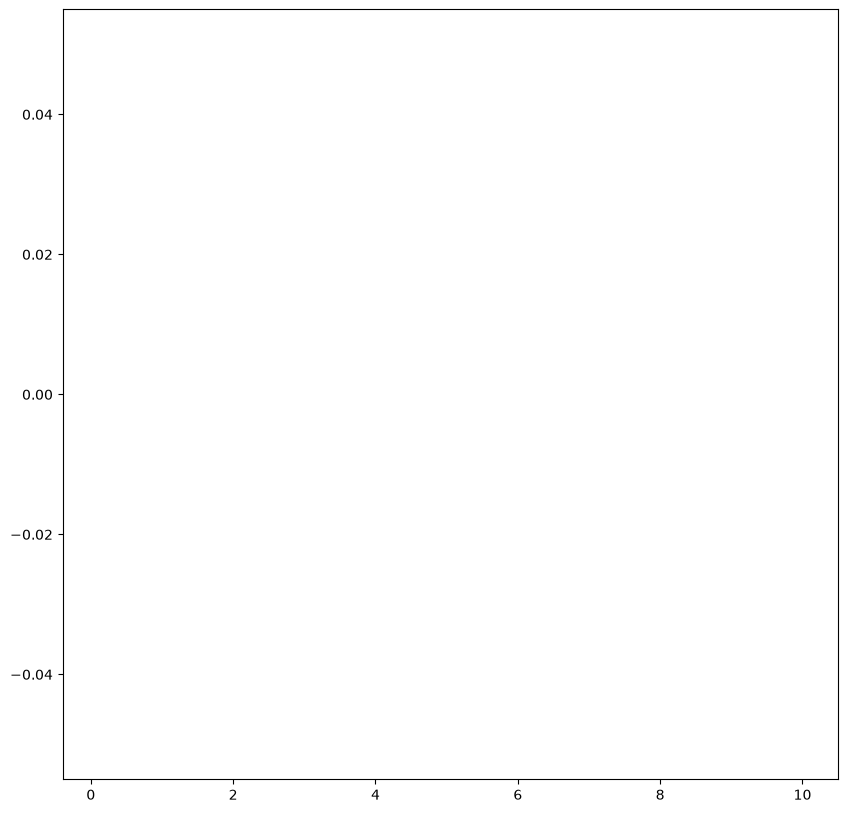

In [63]:
plt.figure(figsize=(10,10))
bins = np.logspace(-1,1, 10)
plt.hist(bay_table_flux_prior['p_i'], bins = bins, )


(array([478.,   2.,  20.,   2.,   0.,  35.,   7.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   3.,   4.,   6.,   7.,   0.,   1.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.]),
 array([0.        , 0.00102564, 0.00205128, 0.00307692, 0.00410256,
        0.00512821, 0.00615385, 0.00717949, 0.00820513, 0.00923077,
        0.01025641, 0.01128205, 0.01230769, 0.01333333, 0.01435897,
        0.01538462, 0.01641026, 0.0174359 , 0.01846154, 0.01948718,
        0.02051282, 0.02153846, 0.0225641 , 0.02358974, 0.02461538,
        0.02564103, 0.02666667, 0.02769231, 0.02871795, 0.02974359,
        0.03076923, 0.03179487, 0.03282051, 0.03384615, 0.03487179,
        0.03589744, 0.03692308, 0.03794872, 0.03897436, 0.04      ]),
 <BarContainer object of 39 artists>)

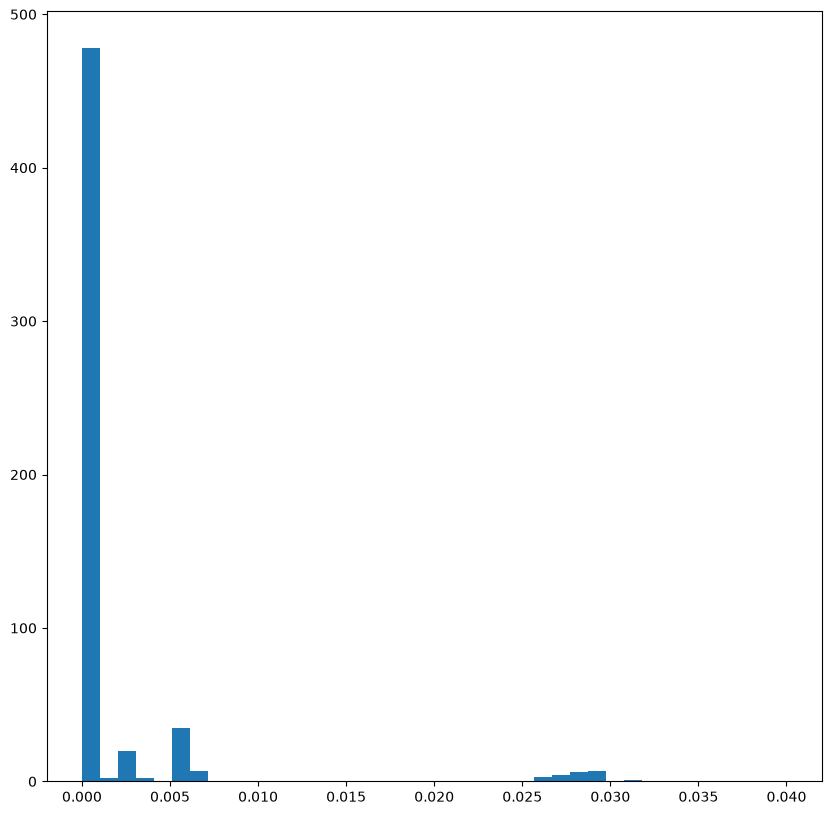

In [52]:
plt.figure(figsize=(10,10))
bins = np.linspace(0,0.04, 40)
plt.hist(bay_table_flux_prior['p_i'], bins = bins, )

In [ ]:
# add gaia sources, wants probability distribution plot of the bayesian postierors 

In [ ]:
# histogram plot of the posteirr in different ways 

In [119]:
catalog_fermi_nway_send = '/Users/mario/Coding/nrao_reu_research/socorro/USSCataloging/reduced_catalogs/send/'

In [9]:
bay_table_flux_prior_gaia = QTable.read(catalog_fermi_nway_send+'4FGL_J0041.3-0048_GM_flux.fits', format='fits')

In [11]:
bay_table_flux_prior_gaia[bay_table_flux_prior_gaia['match_flag']==2]

FERMI_Source_Name,FERMI_DataRelease,FERMI_RA,FERMI_DEC,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_LP_EPeak,FERMI_Unc_LP_EPeak,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_Unc_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_PLEC_EPeak,FERMI_Unc_PLEC_EPeak,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_TEVCAT_FLAG,FERMI_CLASS1,FERMI_CLASS2,FERMI_ASSOC1,FERMI_ASSOC2,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_RA_Counterpart,FERMI_DEC_Counterpart,FERMI_Unc_Counterpart,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_id_x,FERMI_pbeam_version,FERMI_ref_freq,FERMI_maj_restoring_beam,FERMI_min_restoring_beam,FERMI_pa_restoring_beam,FERMI_sigma_1,FERMI_sigma_2,FERMI_sigma_20,FERMI_source_id,FERMI_metadata_id,FERMI_distance_pointing,FERMI_distance_nn,FERMI_s_code,FERMI_n_gauss,FERMI_maxsep_gauss,FERMI_maj,FERMI_maj_e,FERMI_min,FERMI_min_e,FERMI_pa,FERMI_pa_e,FERMI_dc_maj,FERMI_dc_maj_e,FERMI_dc_min,FERMI_dc_min_e,FERMI_dc_pa,FERMI_dc_pa_e,FERMI_ra_mean_e,FERMI_dec_mean_e,FERMI_ra_max,FERMI_ra_max_e,FERMI_dec_max,FERMI_dec_max_e,FERMI_total_flux,FERMI_total_flux_e,FERMI_total_flux_e_fit,FERMI_total_flux_e_sys,FERMI_total_flux_measured,FERMI_total_flux_measured_e,FERMI_peak_flux,FERMI_peak_flux_e,FERMI_isl_total_flux,FERMI_isl_total_flux_e,FERMI_isl_rms,FERMI_isl_mean,FERMI_resid_isl_rms,FERMI_resid_isl_mean,FERMI_flux_correction,FERMI_id_y,FERMI_FluxRatio,FERMI_pos_err,FERMI_ID,MALS_L_DataRelease,MALS_L_RA,MALS_L_DEC,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS_L_PL_Flux_Density,MALS_L_Unc_PL_Flux_Density,MALS_L_PL_Index,MALS_L_Unc_PL_Index,MALS_L_LP_Flux_Density,MALS_L_Unc_LP_Flux_Density,MALS_L_LP_Index,MALS_L_Unc_LP_Index,MALS_L_LP_beta,MALS_L_Unc_LP_beta,MALS_L_LP_SigCurv,MALS_L_LP_EPeak,MALS_L_Unc_LP_EPeak,MALS_L_PLEC_Flux_Density,MALS_L_Unc_PLEC_Flux_Density,MALS_L_PLEC_IndexS,MALS_L_Unc_PLEC_IndexS,MALS_L_PLEC_ExpfactorS,MALS_L_Unc_PLEC_ExpfactorS,MALS_L_PLEC_Exp_Index,MALS_L_Unc_PLEC_Exp_Index,MALS_L_PLEC_SigCurv,MALS_L_PLEC_EPeak,MALS_L_Unc_PLEC_EPeak,MALS_L_Npred,MALS_L_Flux_Band,MALS_L_Unc_Flux_Band,MALS_L_nuFnu_Band,MALS_L_Sqrt_TS_Band,MALS_L_Variability_Index,MALS_L_Frac_Variability,MALS_L_Unc_Frac_Variability,MALS_L_Signif_Peak,MALS_L_Flux_Peak,MALS_L_Unc_Flux_Peak,MALS_L_Time_Peak,MALS_L_Peak_Interval,MALS_L_Flux_History,MALS_L_Unc_Flux_History,MALS_L_Sqrt_TS_History,MALS_L_ASSOC_PROB_BAY,MALS_L_ASSOC_PROB_LR,MALS_L_RA_Counterpart,MALS_L_DEC_Counterpart,MALS_L_Unc_Counterpart,MALS_L_Flags,MALS_L_Indexes,MALS_L_catalog_names,MALS_L_id_x,MALS_L_pointing_name,MALS_L_obs_date_l,MALS_L_obs_band,MALS_L_pbeam_version,MALS_L_fluxcal,MALS_L_fluxscale,MALS_L_spw_id,MALS_L_ref_freq,MALS_L_maj_restoring_beam,MALS_L_min_restoring_beam,MALS_L_pa_restoring_beam,MALS_L_sigma_1,MALS_L_sigma_2,MALS_L_sigma_20,MALS_L_source_id,MALS_L_metadata_id,MALS_L_source_name,MALS_L_distance_pointing,MALS_L_distance_nn,MALS_L_s_code,M

In [130]:
sum(bay_table_flux_prior_gaia['p_any'])

np.float32(28405.605)

In [125]:
bay_table_flux_prior_gaia['p_absolute'] = bay_table_flux_prior_gaia['p_i'] *bay_table_flux_prior_gaia['p_any']

In [138]:
bay_table_flux_prior_gaia.write(catalog_fermi_nway_send+'4FGL_J0041.3-0048_bay_distance_flux_match.fits', format='fits', overwrite='True')

In [127]:
sum(bay_table_flux_prior_gaia['p_absolute'])

np.float32(0.11061652)

In [78]:
bay_table_flux_prior_gaia['p_i'].max()

np.float32(0.49533445)

In [99]:
print(bay_table_flux_prior_gaia[bay_table_flux_prior_gaia['p_i']> 0.05])

FERMI_Source_Name FERMI_DataRelease      FERMI_RA      ...    p_i     match_flag
----------------- ----------------- ------------------ ... ---------- ----------
4FGL J0041.3-0048                 4 10.332200050354004 ... 0.12869406          0
4FGL J0041.3-0048                 4 10.332200050354004 ... 0.49533445          1
4FGL J0041.3-0048                 4 10.332200050354004 ... 0.13012116          0
4FGL J0041.3-0048                 4 10.332200050354004 ... 0.12231566          0
4FGL J0041.3-0048                 4 10.332200050354004 ... 0.06559172          0


In [12]:
bay_table_flux_prior_gaia

FERMI_Source_Name,FERMI_DataRelease,FERMI_RA,FERMI_DEC,FERMI_GLON,FERMI_GLAT,FERMI_Conf_68_SemiMajor,FERMI_Conf_68_SemiMinor,FERMI_Conf_68_PosAng,FERMI_Conf_95_SemiMajor,FERMI_Conf_95_SemiMinor,FERMI_Conf_95_PosAng,FERMI_ROI_num,FERMI_Signif_Avg,FERMI_Pivot_Energy,FERMI_Flux1000,FERMI_Unc_Flux1000,FERMI_Energy_Flux100,FERMI_Unc_Energy_Flux100,FERMI_SpectrumType,FERMI_PL_Flux_Density,FERMI_Unc_PL_Flux_Density,FERMI_PL_Index,FERMI_Unc_PL_Index,FERMI_LP_Flux_Density,FERMI_Unc_LP_Flux_Density,FERMI_LP_Index,FERMI_Unc_LP_Index,FERMI_LP_beta,FERMI_Unc_LP_beta,FERMI_LP_SigCurv,FERMI_LP_EPeak,FERMI_Unc_LP_EPeak,FERMI_PLEC_Flux_Density,FERMI_Unc_PLEC_Flux_Density,FERMI_PLEC_IndexS,FERMI_Unc_PLEC_IndexS,FERMI_PLEC_ExpfactorS,FERMI_Unc_PLEC_ExpfactorS,FERMI_PLEC_Exp_Index,FERMI_Unc_PLEC_Exp_Index,FERMI_PLEC_SigCurv,FERMI_PLEC_EPeak,FERMI_Unc_PLEC_EPeak,FERMI_Npred,FERMI_Flux_Band,FERMI_Unc_Flux_Band,FERMI_nuFnu_Band,FERMI_Sqrt_TS_Band,FERMI_Variability_Index,FERMI_Frac_Variability,FERMI_Unc_Frac_Variability,FERMI_Signif_Peak,FERMI_Flux_Peak,FERMI_Unc_Flux_Peak,FERMI_Time_Peak,FERMI_Peak_Interval,FERMI_Flux_History,FERMI_Unc_Flux_History,FERMI_Sqrt_TS_History,FERMI_TEVCAT_FLAG,FERMI_CLASS1,FERMI_CLASS2,FERMI_ASSOC1,FERMI_ASSOC2,FERMI_ASSOC_PROB_BAY,FERMI_ASSOC_PROB_LR,FERMI_RA_Counterpart,FERMI_DEC_Counterpart,FERMI_Unc_Counterpart,FERMI_Flags,FERMI_Indexes,FERMI_catalog_names,FERMI_id_x,FERMI_pbeam_version,FERMI_ref_freq,FERMI_maj_restoring_beam,FERMI_min_restoring_beam,FERMI_pa_restoring_beam,FERMI_sigma_1,FERMI_sigma_2,FERMI_sigma_20,FERMI_source_id,FERMI_metadata_id,FERMI_distance_pointing,FERMI_distance_nn,FERMI_s_code,FERMI_n_gauss,FERMI_maxsep_gauss,FERMI_maj,FERMI_maj_e,FERMI_min,FERMI_min_e,FERMI_pa,FERMI_pa_e,FERMI_dc_maj,FERMI_dc_maj_e,FERMI_dc_min,FERMI_dc_min_e,FERMI_dc_pa,FERMI_dc_pa_e,FERMI_ra_mean_e,FERMI_dec_mean_e,FERMI_ra_max,FERMI_ra_max_e,FERMI_dec_max,FERMI_dec_max_e,FERMI_total_flux,FERMI_total_flux_e,FERMI_total_flux_e_fit,FERMI_total_flux_e_sys,FERMI_total_flux_measured,FERMI_total_flux_measured_e,FERMI_peak_flux,FERMI_peak_flux_e,FERMI_isl_total_flux,FERMI_isl_total_flux_e,FERMI_isl_rms,FERMI_isl_mean,FERMI_resid_isl_rms,FERMI_resid_isl_mean,FERMI_flux_correction,FERMI_id_y,FERMI_FluxRatio,FERMI_pos_err,FERMI_ID,MALS_L_DataRelease,MALS_L_RA,MALS_L_DEC,MALS_L_GLON,MALS_L_GLAT,MALS_L_Conf_68_SemiMajor,MALS_L_Conf_68_SemiMinor,MALS_L_Conf_68_PosAng,MALS_L_Conf_95_SemiMajor,MALS_L_Conf_95_SemiMinor,MALS_L_Conf_95_PosAng,MALS_L_ROI_num,MALS_L_Signif_Avg,MALS_L_Pivot_Energy,MALS_L_Flux1000,MALS_L_Unc_Flux1000,MALS_L_Energy_Flux100,MALS_L_Unc_Energy_Flux100,MALS_L_PL_Flux_Density,MALS_L_Unc_PL_Flux_Density,MALS_L_PL_Index,MALS_L_Unc_PL_Index,MALS_L_LP_Flux_Density,MALS_L_Unc_LP_Flux_Density,MALS_L_LP_Index,MALS_L_Unc_LP_Index,MALS_L_LP_beta,MALS_L_Unc_LP_beta,MALS_L_LP_SigCurv,MALS_L_LP_EPeak,MALS_L_Unc_LP_EPeak,MALS_L_PLEC_Flux_Density,MALS_L_Unc_PLEC_Flux_Density,MALS_L_PLEC_IndexS,MALS_L_Unc_PLEC_IndexS,MALS_L_PLEC_ExpfactorS,MALS_L_Unc_PLEC_ExpfactorS,MALS_L_PLEC_Exp_Index,MALS_L_Unc_PLEC_Exp_Index,MALS_L_PLEC_SigCurv,MALS_L_PLEC_EPeak,MALS_L_Unc_PLEC_EPeak,MALS_L_Npred,MALS_L_Flux_Band,MALS_L_Unc_Flux_Band,MALS_L_nuFnu_Band,MALS_L_Sqrt_TS_Band,MALS_L_Variability_Index,MALS_L_Frac_Variability,MALS_L_Unc_Frac_Variability,MALS_L_Signif_Peak,MALS_L_Flux_Peak,MALS_L_Unc_Flux_Peak,MALS_L_Time_Peak,MALS_L_Peak_Interval,MALS_L_Flux_History,MALS_L_Unc_Flux_History,MALS_L_Sqrt_TS_History,MALS_L_ASSOC_PROB_BAY,MALS_L_ASSOC_PROB_LR,MALS_L_RA_Counterpart,MALS_L_DEC_Counterpart,MALS_L_Unc_Counterpart,MALS_L_Flags,MALS_L_Indexes,MALS_L_catalog_names,MALS_L_id_x,MALS_L_pointing_name,MALS_L_obs_date_l,MALS_L_obs_band,MALS_L_pbeam_version,MALS_L_fluxcal,MALS_L_fluxscale,MALS_L_spw_id,MALS_L_ref_freq,MALS_L_maj_restoring_beam,MALS_L_min_restoring_beam,MALS_L_pa_restoring_beam,MALS_L_sigma_1,MALS_L_sigma_2,MALS_L_sigma_20,MALS_L_source_id,MALS_L_metadata_id,MALS_L_source_name,MALS_L_distance_pointing,MALS_L_distance_nn,MALS_L_s_code,M

(array([0., 0., 1., 0., 0., 1., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 array([0.01      , 0.01095477, 0.01190955, 0.01286432, 0.0138191 ,
        0.01477387, 0.01572864, 0.0166

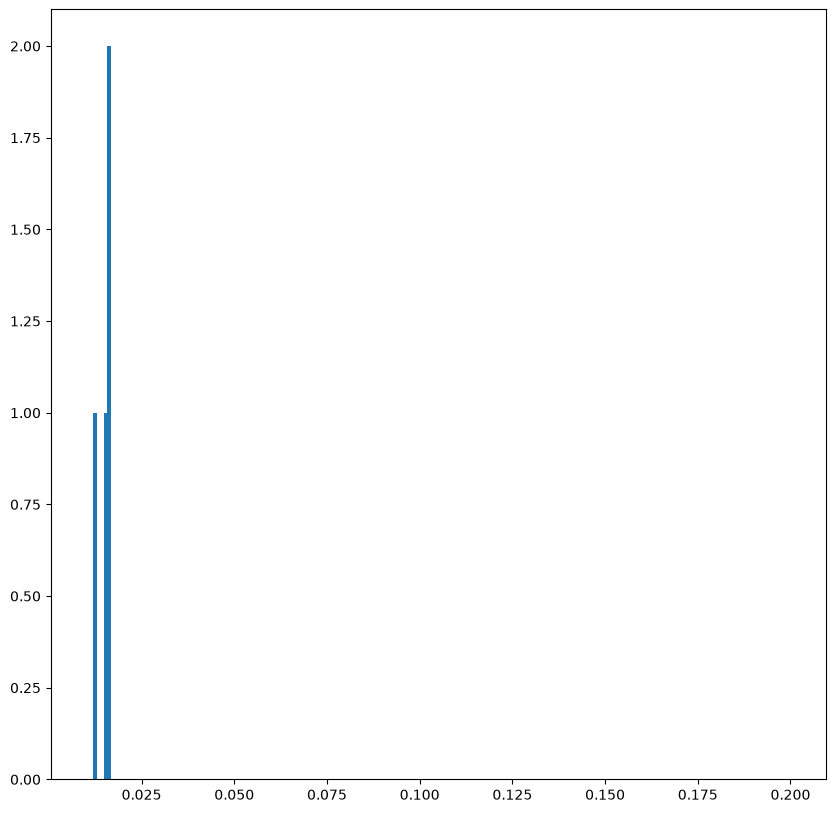

In [26]:
plt.figure(figsize=(10,10))
bins=np.linspace(0.01,0.2, 200)
plt.hist(bay_table_flux_prior_gaia['p_i']*bay_table_flux_prior_gaia['p_any'],bins=bins)

# Creating Primary Component Analysis

#### Creating Associated FERMI Map Catalogs
 (do it with the 14 year source as it is already cross matched with many other sosources)

In [4]:
# group sources into one large catalog for the associated values
catalog_mals_call = '/Users/mario/Coding/nrao_reu_research/socorro/USSCataloging/reduced_catalogs/'
fermi_list_combined = catalog_mals_call  +'14_yr/' + 'MALS_spws_fermi_tables.fits'

fermi_lat_surveys = glob.glob('/Users/mario/Coding/nrao_reu_research/socorro/USSCataloging/catalogs/gll**35.fit')
survey_hud = fits.open(fermi_lat_surveys[0])
fermi_list_14yr = QTable.read(survey_hud, format='fits')

# group the other associated fermi sources with radio cmponents that are not the matches but in the error ellispe range (background)



In [ ]:
clean_class1 = list(set(fermi_list_14yr['CLASS1']))
invalid_tags = ['', 'unk', 'unknown', 'unknow']
class1_valid = [val not in invalid_tags for val in clean_class1]

In [52]:
to_remove = ['', 'unk']
clean_class1 = [val for val in clean_class1 if val not in to_remove]

In [54]:
clean_class1

[np.str_('glc'),
 np.str_('NLSY1'),
 np.str_('MSP'),
 np.str_('GAL'),
 np.str_('pwn'),
 np.str_('hmb'),
 np.str_('HMB'),
 np.str_('msp'),
 np.str_('lmb'),
 np.str_('FSRQ'),
 np.str_('PSR'),
 np.str_('LMB'),
 np.str_('agn'),
 np.str_('nlsy1'),
 np.str_('css'),
 np.str_('fsrq'),
 np.str_('GC'),
 np.str_('RDG'),
 np.str_('SFR'),
 np.str_('BCU'),
 np.str_('psr'),
 np.str_('spp'),
 np.str_('UNK'),
 np.str_('AGN'),
 np.str_('bcu'),
 np.str_('SPP'),
 np.str_('rdg'),
 np.str_('bin'),
 np.str_('ssrq'),
 np.str_('BIN'),
 np.str_('sey'),
 np.str_('BLL'),
 np.str_('sfr'),
 np.str_('SNR'),
 np.str_('gal'),
 np.str_('sbg'),
 np.str_('PWN'),
 np.str_('bll'),
 np.str_('NOV'),
 np.str_('snr')]

In [ ]:
catalog_reduced_dir = '/Users/mario/Coding/nrao_reu_research/socorro/USSCataloging/reduced_catalogs/'

In [ ]:
fermi_list_14yr_done = QTable.read(catalog_reduced_dir + '14yr_grouped_ellipses.fits', format='fits')


In [75]:
fermi_list_14yr_done

Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,Conf_95_PosAng,ROI_num,Extended_Source_Name,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Flux_Density,Unc_PL_Flux_Density,PL_Index,Unc_PL_Index,LP_Flux_Density,Unc_LP_Flux_Density,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,LP_SigCurv,LP_EPeak,Unc_LP_EPeak,PLEC_Flux_Density,Unc_PLEC_Flux_Density,PLEC_IndexS,Unc_PLEC_IndexS,PLEC_ExpfactorS,Unc_PLEC_ExpfactorS,PLEC_Exp_Index,Unc_PLEC_Exp_Index,PLEC_SigCurv,PLEC_EPeak,Unc_PLEC_EPeak,Npred,Flux_Band,Unc_Flux_Band,nuFnu_Band,Sqrt_TS_Band,Variability_Index,Frac_Variability,Unc_Frac_Variability,Signif_Peak,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,Flux_History,Unc_Flux_History,Sqrt_TS_History,ASSOC_4FGL,ASSOC_FGL,ASSOC_FHL,ASSOC_GAM1,ASSOC_GAM2,ASSOC_GAM3,TEVCAT_FLAG,ASSOC_TEV,CLASS1,CLASS2,ASSOC1,ASSOC2,ASSOC_PROB_BAY,ASSOC_PROB_LR,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,Flags,Indexes,catalog_names,closest_spx_idx,NVSS_src1_TGSSADR,NVSS_src1_RAJ2000,NVSS_src1_e_RAJ2000,NVSS_src1_DEJ2000,NVSS_src1_e_DEJ2000,NVSS_src1_Stotal,NVSS_src1_e_Stotal,NVSS_src1_Speak,NVSS_src1_e_Speak,NVSS_src1_Maj,NVSS_src1_e_Maj,NVSS_src1_Min,NVSS_src1_e_Min,NVSS_src1_PA,NVSS_src1_e_PA,NVSS_src1_Noise,NVSS_src1_Code,NVSS_src1_Mosaic,NVSS_src1_ref_freq,NVSS_src1_Indexes,NVSS_src1_ang_sep,NVSS_src1_catalog_names,NVSS_src1_radio_flux_name,NVSS_src1_spectral_index,closest_TGSSADR,closest_RAJ2000,closest_e_RAJ2000,closest_DEJ2000,closest_e_DEJ2000,closest_Stotal,closest_e_Stotal,closest_Speak,closest_e_Speak,closest_Maj,closest_e_Maj,closest_Min,closest_e_Min,closest_PA,closest_e_PA,closest_Noise,closest_Code,closest_Mosaic,closest_ref_freq,closest_Indexes,closest_ang_sep,closest_catalog_names,closest_radio_flux_name,closest_spectral_index,VLASS_src1_CompName,VLASS_src1_CompId,VLASS_src1_IslId,VLASS_src1_RAJ2000,VLASS_src1_DEJ2000,VLASS_src1_e_RAdeg,VLASS_src1_e_DEdeg,VLASS_src1_Ftot,VLASS_src1_e_Ftot,VLASS_src1_Fpeak,VLASS_src1_e_Fpeak,VLASS_src1_Maj,VLASS_src1_e_Maj,VLASS_src1_Min,VLASS_src1_e_Min,VLASS_src1_PA,VLASS_src1_e_PA,VLASS_src1_FtotIsl,VLASS_src1_e_FtotIsl,VLASS_src1_Islrms,VLASS_src1_Islmean,VLASS_src1_ResIdIslrms,VLASS_src1_ResidIslmean,VLASS_src1_RAMdeg,VLASS_src1_DEMdeg,VLASS_src1_e_RAMdeg,VLASS_src1_e_DEMdeg,VLASS_src1_SCode,VLASS_src1_Xposn,VLASS_src1_e_Xposn,VLASS_src1_Yposn,VLASS_src1_e_Yposn,VLASS_src1_XposnMax,VLASS_src1_e_XposnMax,VLASS_src1_YposnMax,VLASS_src1_e_YposnMax,VLASS_src1_MajImgPlane,VLASS_src1_e_MajImgPlane,VLASS_src1_MinImgPlane,VLASS_src1_e_MinImgPlane,VLASS_src1_PAImgPlane,VLASS_src1_e_PAImgPlane,VLASS_src1_DCMaj,VLASS_src1_e_DCMaj,VLASS_src1_DCMin,VLASS_src1_e_DCMin,VLASS_src1_DCPA,VLASS_src1_e_DCPA,VLASS_src1_DCMajImgPlane,VLASS_src1_e_DCMajImgPlane,VLASS_src1_DCMinImgPlane,VLASS_src1_e_DCMinImgPlane,VLASS_src1_DCPAImgPlane,VLASS_src1_e_DCPAImgPlane,VLASS_src1_Tile,VLASS_src1_Subtile,VLASS_src1_RASdeg,VLASS_src1_DESdeg,VLASS_src1_NVSSdist,VLASS_src1_FIRSTdist,VLASS_src1_PeakToRing,VLASS_src1_DupFlag,VLASS_src1_QualFlag,VLASS_src1_NNdist,VLASS_src1_BMaj,VLASS_src1_BMin,VLASS_src1_BPA,VLASS_src1_MainSample,VLASS_src1_QLcutout,VLASS_src1_ref_freq,VLASS_src1_Indexes,VLASS_src1_FluxRatio,VLASS_src1_ang_sep,VLASS_src1_catalog_names,VLASS_src1_radio_flux_name,VLASS_src1_spectral_index,closest_CompName,closest_CompId,closest_IslId,closest_e_RAdeg,closest_e_DEdeg,closest_Ftot,closest_e_Ftot,closest_Fpeak,closest_e_Fpeak,closest_FtotIsl,closest_e_FtotIsl,closest_Islrms,closest_Islmean,closest_ResIdIslrms,closest_ResidIslmean,closest_RAMdeg,closest_DEMdeg,closest_e_RAMdeg,closest_e_DEMdeg,closest_SCode,closest_Xposn,closest_e_Xposn,closest_Yposn,closest_e_Yposn,closest_XposnMax,closest_e_XposnMax,closest_YposnMax,closest_e_YposnMax,closest_MajImgPlane,closest_e_MajImgPlane,closest_MinImgPlane,closest_e_MinImgPlane,closest_PAImgPlane,closest_e_PAImgPlane,closest_DCMaj,closest_e_DCMaj,close

In [ ]:
valid_values = fermi_list_14yr_done[~fermi_list_14yr_done['closest_spx_idx'].mask]

In [ ]:
valid_values

Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,Conf_95_PosAng,ROI_num,Extended_Source_Name,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Flux_Density,Unc_PL_Flux_Density,PL_Index,Unc_PL_Index,LP_Flux_Density,Unc_LP_Flux_Density,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,LP_SigCurv,LP_EPeak,Unc_LP_EPeak,PLEC_Flux_Density,Unc_PLEC_Flux_Density,PLEC_IndexS,Unc_PLEC_IndexS,PLEC_ExpfactorS,Unc_PLEC_ExpfactorS,PLEC_Exp_Index,Unc_PLEC_Exp_Index,PLEC_SigCurv,PLEC_EPeak,Unc_PLEC_EPeak,Npred,Flux_Band,Unc_Flux_Band,nuFnu_Band,Sqrt_TS_Band,Variability_Index,Frac_Variability,Unc_Frac_Variability,Signif_Peak,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,Flux_History,Unc_Flux_History,Sqrt_TS_History,ASSOC_4FGL,ASSOC_FGL,ASSOC_FHL,ASSOC_GAM1,ASSOC_GAM2,ASSOC_GAM3,TEVCAT_FLAG,ASSOC_TEV,CLASS1,CLASS2,ASSOC1,ASSOC2,ASSOC_PROB_BAY,ASSOC_PROB_LR,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,Flags,Indexes,catalog_names,closest_spx_idx,NVSS_src1_TGSSADR,NVSS_src1_RAJ2000,NVSS_src1_e_RAJ2000,NVSS_src1_DEJ2000,NVSS_src1_e_DEJ2000,NVSS_src1_Stotal,NVSS_src1_e_Stotal,NVSS_src1_Speak,NVSS_src1_e_Speak,NVSS_src1_Maj,NVSS_src1_e_Maj,NVSS_src1_Min,NVSS_src1_e_Min,NVSS_src1_PA,NVSS_src1_e_PA,NVSS_src1_Noise,NVSS_src1_Code,NVSS_src1_Mosaic,NVSS_src1_ref_freq,NVSS_src1_Indexes,NVSS_src1_ang_sep,NVSS_src1_catalog_names,NVSS_src1_radio_flux_name,NVSS_src1_spectral_index,closest_TGSSADR,closest_RAJ2000,closest_e_RAJ2000,closest_DEJ2000,closest_e_DEJ2000,closest_Stotal,closest_e_Stotal,closest_Speak,closest_e_Speak,closest_Maj,closest_e_Maj,closest_Min,closest_e_Min,closest_PA,closest_e_PA,closest_Noise,closest_Code,closest_Mosaic,closest_ref_freq,closest_Indexes,closest_ang_sep,closest_catalog_names,closest_radio_flux_name,closest_spectral_index,VLASS_src1_CompName,VLASS_src1_CompId,VLASS_src1_IslId,VLASS_src1_RAJ2000,VLASS_src1_DEJ2000,VLASS_src1_e_RAdeg,VLASS_src1_e_DEdeg,VLASS_src1_Ftot,VLASS_src1_e_Ftot,VLASS_src1_Fpeak,VLASS_src1_e_Fpeak,VLASS_src1_Maj,VLASS_src1_e_Maj,VLASS_src1_Min,VLASS_src1_e_Min,VLASS_src1_PA,VLASS_src1_e_PA,VLASS_src1_FtotIsl,VLASS_src1_e_FtotIsl,VLASS_src1_Islrms,VLASS_src1_Islmean,VLASS_src1_ResIdIslrms,VLASS_src1_ResidIslmean,VLASS_src1_RAMdeg,VLASS_src1_DEMdeg,VLASS_src1_e_RAMdeg,VLASS_src1_e_DEMdeg,VLASS_src1_SCode,VLASS_src1_Xposn,VLASS_src1_e_Xposn,VLASS_src1_Yposn,VLASS_src1_e_Yposn,VLASS_src1_XposnMax,VLASS_src1_e_XposnMax,VLASS_src1_YposnMax,VLASS_src1_e_YposnMax,VLASS_src1_MajImgPlane,VLASS_src1_e_MajImgPlane,VLASS_src1_MinImgPlane,VLASS_src1_e_MinImgPlane,VLASS_src1_PAImgPlane,VLASS_src1_e_PAImgPlane,VLASS_src1_DCMaj,VLASS_src1_e_DCMaj,VLASS_src1_DCMin,VLASS_src1_e_DCMin,VLASS_src1_DCPA,VLASS_src1_e_DCPA,VLASS_src1_DCMajImgPlane,VLASS_src1_e_DCMajImgPlane,VLASS_src1_DCMinImgPlane,VLASS_src1_e_DCMinImgPlane,VLASS_src1_DCPAImgPlane,VLASS_src1_e_DCPAImgPlane,VLASS_src1_Tile,VLASS_src1_Subtile,VLASS_src1_RASdeg,VLASS_src1_DESdeg,VLASS_src1_NVSSdist,VLASS_src1_FIRSTdist,VLASS_src1_PeakToRing,VLASS_src1_DupFlag,VLASS_src1_QualFlag,VLASS_src1_NNdist,VLASS_src1_BMaj,VLASS_src1_BMin,VLASS_src1_BPA,VLASS_src1_MainSample,VLASS_src1_QLcutout,VLASS_src1_ref_freq,VLASS_src1_Indexes,VLASS_src1_FluxRatio,VLASS_src1_ang_sep,VLASS_src1_catalog_names,VLASS_src1_radio_flux_name,VLASS_src1_spectral_index,closest_CompName,closest_CompId,closest_IslId,closest_e_RAdeg,closest_e_DEdeg,closest_Ftot,closest_e_Ftot,closest_Fpeak,closest_e_Fpeak,closest_FtotIsl,closest_e_FtotIsl,closest_Islrms,closest_Islmean,closest_ResIdIslrms,closest_ResidIslmean,closest_RAMdeg,closest_DEMdeg,closest_e_RAMdeg,closest_e_DEMdeg,closest_SCode,closest_Xposn,closest_e_Xposn,closest_Yposn,closest_e_Yposn,closest_XposnMax,closest_e_XposnMax,closest_YposnMax,closest_e_YposnMax,closest_MajImgPlane,closest_e_MajImgPlane,closest_MinImgPlane,closest_e_MinImgPlane,closest_PAImgPlane,closest_e_PAImgPlane,closest_DCMaj,closest_e_DCMaj,close

<>:65: SyntaxWarning: invalid escape sequence '\G'
<>:65: SyntaxWarning: invalid escape sequence '\G'
C:\Users\mario\AppData\Local\Temp\ipykernel_35488\2200000221.py:65: SyntaxWarning: invalid escape sequence '\G'
  plt.xlabel('Gamma-Ray Photon Index ($\Gamma - 1$)')


bll
fsrq
BLL
fsrq
bll
bcu
bll
bll
bll
bll
fsrq
bll
fsrq
bll
fsrq
FSRQ
fsrq
fsrq
FSRQ
rdg
fsrq
FSRQ
bll
FSRQ
bll
snr
bll
fsrq
bll
bll
bll
bll
fsrq


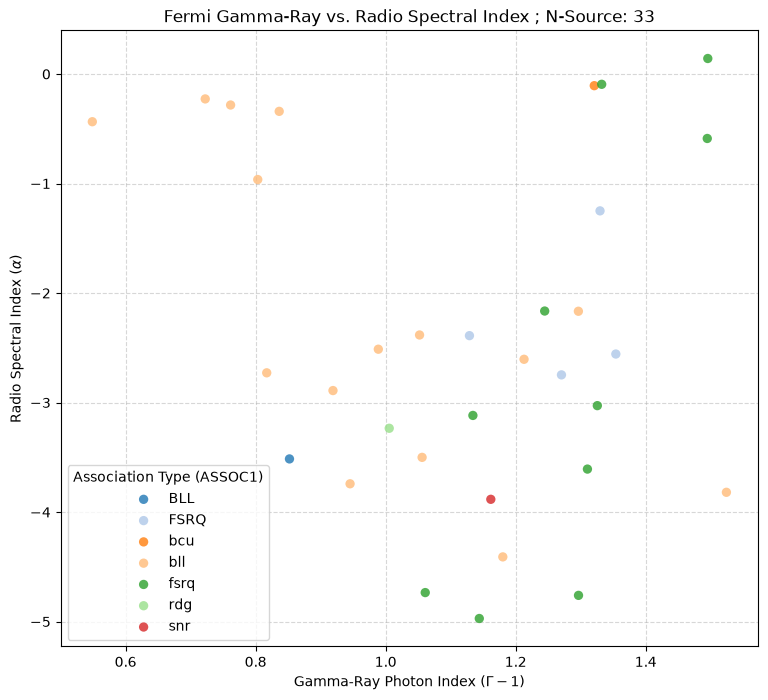

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Your predefined list of expected uppercase Fermi LAT association classes

radio_alphas = []
fermi_alphas = []
assoc_categories = []  # To store the matched categories

for source in valid_values:
    # Extract Fermi Gamma-Ray Index
    if source['SpectrumType'] == 'LogParabola':
        fermi_alpha = source['LP_Index'] - 1
    else:
        fermi_alpha = source['PL_Index'] - 1
        
    # Extract Radio Spectral Index
    radio_alpha = source['closest_spx_idx']
    
    # Direct match against your uppercase list
    raw_assoc = source['CLASS1']
    print(raw_assoc)
    if raw_assoc in clean_class1:
        matched_category = raw_assoc
    else:
        matched_category = 'OTHER'
        
    radio_alphas.append(radio_alpha)
    fermi_alphas.append(fermi_alpha)
    assoc_categories.append(matched_category)

# Convert to arrays for masking
fermi_alphas = np.array(fermi_alphas)
radio_alphas = np.array(radio_alphas)
assoc_categories = np.array(assoc_categories)

# plot
plt.figure(figsize=(9, 8))
cmap = plt.get_cmap('tab20')

# Extract unique classes actually present in the data to build a clean legend
unique_present_classes = np.unique(assoc_categories)

for i, cls in enumerate(unique_present_classes):
    mask = (assoc_categories == cls)
    
    if cls == 'OTHER':
        plot_color = 'gray'
        plot_zorder = 1
    else:
        plot_color = cmap(i % 10)
        plot_zorder = 2
        
    plt.scatter(
        fermi_alphas[mask], 
        radio_alphas[mask], 
        label=cls, 
        color=plot_color, 
        alpha=0.8, 
        edgecolors='none', 
        s=45,
        zorder=plot_zorder
    )

plt.xlabel('Gamma-Ray Photon Index ($\Gamma - 1$)')
plt.ylabel('Radio Spectral Index ($\\alpha$)')
plt.title(f'Fermi Gamma-Ray vs. Radio Spectral Index ; N-Source: {len(valid_values)}')

plt.legend(title="Association Type (ASSOC1)", loc="best", frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [39]:
mask = np.isin(fermi_list_14yr_done['closest_MainSample'], 'masked')
fermi_list_14yr_done[mask]

Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,Conf_95_PosAng,ROI_num,Extended_Source_Name,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Flux_Density,Unc_PL_Flux_Density,PL_Index,Unc_PL_Index,LP_Flux_Density,Unc_LP_Flux_Density,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,LP_SigCurv,LP_EPeak,Unc_LP_EPeak,PLEC_Flux_Density,Unc_PLEC_Flux_Density,PLEC_IndexS,Unc_PLEC_IndexS,PLEC_ExpfactorS,Unc_PLEC_ExpfactorS,PLEC_Exp_Index,Unc_PLEC_Exp_Index,PLEC_SigCurv,PLEC_EPeak,Unc_PLEC_EPeak,Npred,Flux_Band,Unc_Flux_Band,nuFnu_Band,Sqrt_TS_Band,Variability_Index,Frac_Variability,Unc_Frac_Variability,Signif_Peak,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,Flux_History,Unc_Flux_History,Sqrt_TS_History,ASSOC_4FGL,ASSOC_FGL,ASSOC_FHL,ASSOC_GAM1,ASSOC_GAM2,ASSOC_GAM3,TEVCAT_FLAG,ASSOC_TEV,CLASS1,CLASS2,ASSOC1,ASSOC2,ASSOC_PROB_BAY,ASSOC_PROB_LR,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,Flags,Indexes,catalog_names,closest_spx_idx,NVSS_TGSSADR,NVSS_RAJ2000,NVSS_e_RAJ2000,NVSS_DEJ2000,NVSS_e_DEJ2000,NVSS_Stotal,NVSS_e_Stotal,NVSS_Speak,NVSS_e_Speak,NVSS_Maj,NVSS_e_Maj,NVSS_Min,NVSS_e_Min,NVSS_PA,NVSS_e_PA,NVSS_Noise,NVSS_Code,NVSS_Mosaic,NVSS_ref_freq,NVSS_Indexes,NVSS_ang_sep,NVSS_catalog_names,NVSS_radio_flux_name,NVSS_spectral_index,closest_TGSSADR,closest_RAJ2000,closest_e_RAJ2000,closest_DEJ2000,closest_e_DEJ2000,closest_Stotal,closest_e_Stotal,closest_Speak,closest_e_Speak,closest_Maj,closest_e_Maj,closest_Min,closest_e_Min,closest_PA,closest_e_PA,closest_Noise,closest_Code,closest_Mosaic,closest_ref_freq,closest_Indexes,closest_ang_sep,closest_catalog_names,closest_radio_flux_name,closest_spectral_index,VLASS_CompName,VLASS_CompId,VLASS_IslId,VLASS_RAJ2000,VLASS_DEJ2000,VLASS_e_RAdeg,VLASS_e_DEdeg,VLASS_Ftot,VLASS_e_Ftot,VLASS_Fpeak,VLASS_e_Fpeak,VLASS_Maj,VLASS_e_Maj,VLASS_Min,VLASS_e_Min,VLASS_PA,VLASS_e_PA,VLASS_FtotIsl,VLASS_e_FtotIsl,VLASS_Islrms,VLASS_Islmean,VLASS_ResIdIslrms,VLASS_ResidIslmean,VLASS_RAMdeg,VLASS_DEMdeg,VLASS_e_RAMdeg,VLASS_e_DEMdeg,VLASS_SCode,VLASS_Xposn,VLASS_e_Xposn,VLASS_Yposn,VLASS_e_Yposn,VLASS_XposnMax,VLASS_e_XposnMax,VLASS_YposnMax,VLASS_e_YposnMax,VLASS_MajImgPlane,VLASS_e_MajImgPlane,VLASS_MinImgPlane,VLASS_e_MinImgPlane,VLASS_PAImgPlane,VLASS_e_PAImgPlane,VLASS_DCMaj,VLASS_e_DCMaj,VLASS_DCMin,VLASS_e_DCMin,VLASS_DCPA,VLASS_e_DCPA,VLASS_DCMajImgPlane,VLASS_e_DCMajImgPlane,VLASS_DCMinImgPlane,VLASS_e_DCMinImgPlane,VLASS_DCPAImgPlane,VLASS_e_DCPAImgPlane,VLASS_Tile,VLASS_Subtile,VLASS_RASdeg,VLASS_DESdeg,VLASS_NVSSdist,VLASS_FIRSTdist,VLASS_PeakToRing,VLASS_DupFlag,VLASS_QualFlag,VLASS_NNdist,VLASS_BMaj,VLASS_BMin,VLASS_BPA,VLASS_MainSample,VLASS_QLcutout,VLASS_ref_freq,VLASS_Indexes,VLASS_FluxRatio,VLASS_ang_sep,VLASS_catalog_names,VLASS_radio_flux_name,VLASS_spectral_index,closest_CompName,closest_CompId,closest_IslId,closest_e_RAdeg,closest_e_DEdeg,closest_Ftot,closest_e_Ftot,closest_Fpeak,closest_e_Fpeak,closest_FtotIsl,closest_e_FtotIsl,closest_Islrms,closest_Islmean,closest_ResIdIslrms,closest_ResidIslmean,closest_RAMdeg,closest_DEMdeg,closest_e_RAMdeg,closest_e_DEMdeg,closest_SCode,closest_Xposn,closest_e_Xposn,closest_Yposn,closest_e_Yposn,closest_XposnMax,closest_e_XposnMax,closest_YposnMax,closest_e_YposnMax,closest_MajImgPlane,closest_e_MajImgPlane,closest_MinImgPlane,closest_e_MinImgPlane,closest_PAImgPlane,closest_e_PAImgPlane,closest_DCMaj,closest_e_DCMaj,closest_DCMin,closest_e_DCMin,closest_DCPA,closest_e_DCPA,closest_DCMajImgPlane,closest_e_DCMajImgPlane,closest_DCMinImgPlane,closest_e_DCMinImgPlane,closest_DCPAImgPlane,closest_e_DCPAImgPlane,closest_Tile,closest_Subtile,closest_RASdeg,closest_DESdeg,closest_NVSSdist,closest_FIRSTdist,closest_PeakToRing,closest_DupFlag,closest_QualFlag,closest_NNdist,closest_BMaj,closest_BMin,closest_BPA,closest_MainSample,closest_QLcutout,closest_FluxRatio
,,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,,,,MeV,ph / (s c

In [31]:
fermi_list_14yr_done[~mask]

Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,Conf_95_PosAng,ROI_num,Extended_Source_Name,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Flux_Density,Unc_PL_Flux_Density,PL_Index,Unc_PL_Index,LP_Flux_Density,Unc_LP_Flux_Density,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,LP_SigCurv,LP_EPeak,Unc_LP_EPeak,PLEC_Flux_Density,Unc_PLEC_Flux_Density,PLEC_IndexS,Unc_PLEC_IndexS,PLEC_ExpfactorS,Unc_PLEC_ExpfactorS,PLEC_Exp_Index,Unc_PLEC_Exp_Index,PLEC_SigCurv,PLEC_EPeak,Unc_PLEC_EPeak,Npred,Flux_Band,Unc_Flux_Band,nuFnu_Band,Sqrt_TS_Band,Variability_Index,Frac_Variability,Unc_Frac_Variability,Signif_Peak,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,Flux_History,Unc_Flux_History,Sqrt_TS_History,ASSOC_4FGL,ASSOC_FGL,ASSOC_FHL,ASSOC_GAM1,ASSOC_GAM2,ASSOC_GAM3,TEVCAT_FLAG,ASSOC_TEV,CLASS1,CLASS2,ASSOC1,ASSOC2,ASSOC_PROB_BAY,ASSOC_PROB_LR,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,Flags,Indexes,catalog_names,closest_spx_idx,NVSS_TGSSADR,NVSS_RAJ2000,NVSS_e_RAJ2000,NVSS_DEJ2000,NVSS_e_DEJ2000,NVSS_Stotal,NVSS_e_Stotal,NVSS_Speak,NVSS_e_Speak,NVSS_Maj,NVSS_e_Maj,NVSS_Min,NVSS_e_Min,NVSS_PA,NVSS_e_PA,NVSS_Noise,NVSS_Code,NVSS_Mosaic,NVSS_ref_freq,NVSS_Indexes,NVSS_ang_sep,NVSS_catalog_names,NVSS_radio_flux_name,NVSS_spectral_index,closest_TGSSADR,closest_RAJ2000,closest_e_RAJ2000,closest_DEJ2000,closest_e_DEJ2000,closest_Stotal,closest_e_Stotal,closest_Speak,closest_e_Speak,closest_Maj,closest_e_Maj,closest_Min,closest_e_Min,closest_PA,closest_e_PA,closest_Noise,closest_Code,closest_Mosaic,closest_ref_freq,closest_Indexes,closest_ang_sep,closest_catalog_names,closest_radio_flux_name,closest_spectral_index,VLASS_CompName,VLASS_CompId,VLASS_IslId,VLASS_RAJ2000,VLASS_DEJ2000,VLASS_e_RAdeg,VLASS_e_DEdeg,VLASS_Ftot,VLASS_e_Ftot,VLASS_Fpeak,VLASS_e_Fpeak,VLASS_Maj,VLASS_e_Maj,VLASS_Min,VLASS_e_Min,VLASS_PA,VLASS_e_PA,VLASS_FtotIsl,VLASS_e_FtotIsl,VLASS_Islrms,VLASS_Islmean,VLASS_ResIdIslrms,VLASS_ResidIslmean,VLASS_RAMdeg,VLASS_DEMdeg,VLASS_e_RAMdeg,VLASS_e_DEMdeg,VLASS_SCode,VLASS_Xposn,VLASS_e_Xposn,VLASS_Yposn,VLASS_e_Yposn,VLASS_XposnMax,VLASS_e_XposnMax,VLASS_YposnMax,VLASS_e_YposnMax,VLASS_MajImgPlane,VLASS_e_MajImgPlane,VLASS_MinImgPlane,VLASS_e_MinImgPlane,VLASS_PAImgPlane,VLASS_e_PAImgPlane,VLASS_DCMaj,VLASS_e_DCMaj,VLASS_DCMin,VLASS_e_DCMin,VLASS_DCPA,VLASS_e_DCPA,VLASS_DCMajImgPlane,VLASS_e_DCMajImgPlane,VLASS_DCMinImgPlane,VLASS_e_DCMinImgPlane,VLASS_DCPAImgPlane,VLASS_e_DCPAImgPlane,VLASS_Tile,VLASS_Subtile,VLASS_RASdeg,VLASS_DESdeg,VLASS_NVSSdist,VLASS_FIRSTdist,VLASS_PeakToRing,VLASS_DupFlag,VLASS_QualFlag,VLASS_NNdist,VLASS_BMaj,VLASS_BMin,VLASS_BPA,VLASS_MainSample,VLASS_QLcutout,VLASS_ref_freq,VLASS_Indexes,VLASS_FluxRatio,VLASS_ang_sep,VLASS_catalog_names,VLASS_radio_flux_name,VLASS_spectral_index,closest_CompName,closest_CompId,closest_IslId,closest_e_RAdeg,closest_e_DEdeg,closest_Ftot,closest_e_Ftot,closest_Fpeak,closest_e_Fpeak,closest_FtotIsl,closest_e_FtotIsl,closest_Islrms,closest_Islmean,closest_ResIdIslrms,closest_ResidIslmean,closest_RAMdeg,closest_DEMdeg,closest_e_RAMdeg,closest_e_DEMdeg,closest_SCode,closest_Xposn,closest_e_Xposn,closest_Yposn,closest_e_Yposn,closest_XposnMax,closest_e_XposnMax,closest_YposnMax,closest_e_YposnMax,closest_MajImgPlane,closest_e_MajImgPlane,closest_MinImgPlane,closest_e_MinImgPlane,closest_PAImgPlane,closest_e_PAImgPlane,closest_DCMaj,closest_e_DCMaj,closest_DCMin,closest_e_DCMin,closest_DCPA,closest_e_DCPA,closest_DCMajImgPlane,closest_e_DCMajImgPlane,closest_DCMinImgPlane,closest_e_DCMinImgPlane,closest_DCPAImgPlane,closest_e_DCPAImgPlane,closest_Tile,closest_Subtile,closest_RASdeg,closest_DESdeg,closest_NVSSdist,closest_FIRSTdist,closest_PeakToRing,closest_DupFlag,closest_QualFlag,closest_NNdist,closest_BMaj,closest_BMin,closest_BPA,closest_MainSample,closest_QLcutout,closest_FluxRatio
,,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,,,,MeV,ph / (s c

In [29]:
mask = np.isin(fermi_list_14yr_done['closest_MainSample'], '--')
fermi_list_14yr_done[~mask]

Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Conf_68_SemiMajor,Conf_68_SemiMinor,Conf_68_PosAng,Conf_95_SemiMajor,Conf_95_SemiMinor,Conf_95_PosAng,ROI_num,Extended_Source_Name,Signif_Avg,Pivot_Energy,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Flux_Density,Unc_PL_Flux_Density,PL_Index,Unc_PL_Index,LP_Flux_Density,Unc_LP_Flux_Density,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,LP_SigCurv,LP_EPeak,Unc_LP_EPeak,PLEC_Flux_Density,Unc_PLEC_Flux_Density,PLEC_IndexS,Unc_PLEC_IndexS,PLEC_ExpfactorS,Unc_PLEC_ExpfactorS,PLEC_Exp_Index,Unc_PLEC_Exp_Index,PLEC_SigCurv,PLEC_EPeak,Unc_PLEC_EPeak,Npred,Flux_Band,Unc_Flux_Band,nuFnu_Band,Sqrt_TS_Band,Variability_Index,Frac_Variability,Unc_Frac_Variability,Signif_Peak,Flux_Peak,Unc_Flux_Peak,Time_Peak,Peak_Interval,Flux_History,Unc_Flux_History,Sqrt_TS_History,ASSOC_4FGL,ASSOC_FGL,ASSOC_FHL,ASSOC_GAM1,ASSOC_GAM2,ASSOC_GAM3,TEVCAT_FLAG,ASSOC_TEV,CLASS1,CLASS2,ASSOC1,ASSOC2,ASSOC_PROB_BAY,ASSOC_PROB_LR,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,Flags,Indexes,catalog_names,closest_spx_idx,NVSS_TGSSADR,NVSS_RAJ2000,NVSS_e_RAJ2000,NVSS_DEJ2000,NVSS_e_DEJ2000,NVSS_Stotal,NVSS_e_Stotal,NVSS_Speak,NVSS_e_Speak,NVSS_Maj,NVSS_e_Maj,NVSS_Min,NVSS_e_Min,NVSS_PA,NVSS_e_PA,NVSS_Noise,NVSS_Code,NVSS_Mosaic,NVSS_ref_freq,NVSS_Indexes,NVSS_ang_sep,NVSS_catalog_names,NVSS_radio_flux_name,NVSS_spectral_index,closest_TGSSADR,closest_RAJ2000,closest_e_RAJ2000,closest_DEJ2000,closest_e_DEJ2000,closest_Stotal,closest_e_Stotal,closest_Speak,closest_e_Speak,closest_Maj,closest_e_Maj,closest_Min,closest_e_Min,closest_PA,closest_e_PA,closest_Noise,closest_Code,closest_Mosaic,closest_ref_freq,closest_Indexes,closest_ang_sep,closest_catalog_names,closest_radio_flux_name,closest_spectral_index,VLASS_CompName,VLASS_CompId,VLASS_IslId,VLASS_RAJ2000,VLASS_DEJ2000,VLASS_e_RAdeg,VLASS_e_DEdeg,VLASS_Ftot,VLASS_e_Ftot,VLASS_Fpeak,VLASS_e_Fpeak,VLASS_Maj,VLASS_e_Maj,VLASS_Min,VLASS_e_Min,VLASS_PA,VLASS_e_PA,VLASS_FtotIsl,VLASS_e_FtotIsl,VLASS_Islrms,VLASS_Islmean,VLASS_ResIdIslrms,VLASS_ResidIslmean,VLASS_RAMdeg,VLASS_DEMdeg,VLASS_e_RAMdeg,VLASS_e_DEMdeg,VLASS_SCode,VLASS_Xposn,VLASS_e_Xposn,VLASS_Yposn,VLASS_e_Yposn,VLASS_XposnMax,VLASS_e_XposnMax,VLASS_YposnMax,VLASS_e_YposnMax,VLASS_MajImgPlane,VLASS_e_MajImgPlane,VLASS_MinImgPlane,VLASS_e_MinImgPlane,VLASS_PAImgPlane,VLASS_e_PAImgPlane,VLASS_DCMaj,VLASS_e_DCMaj,VLASS_DCMin,VLASS_e_DCMin,VLASS_DCPA,VLASS_e_DCPA,VLASS_DCMajImgPlane,VLASS_e_DCMajImgPlane,VLASS_DCMinImgPlane,VLASS_e_DCMinImgPlane,VLASS_DCPAImgPlane,VLASS_e_DCPAImgPlane,VLASS_Tile,VLASS_Subtile,VLASS_RASdeg,VLASS_DESdeg,VLASS_NVSSdist,VLASS_FIRSTdist,VLASS_PeakToRing,VLASS_DupFlag,VLASS_QualFlag,VLASS_NNdist,VLASS_BMaj,VLASS_BMin,VLASS_BPA,VLASS_MainSample,VLASS_QLcutout,VLASS_ref_freq,VLASS_Indexes,VLASS_FluxRatio,VLASS_ang_sep,VLASS_catalog_names,VLASS_radio_flux_name,VLASS_spectral_index,closest_CompName,closest_CompId,closest_IslId,closest_e_RAdeg,closest_e_DEdeg,closest_Ftot,closest_e_Ftot,closest_Fpeak,closest_e_Fpeak,closest_FtotIsl,closest_e_FtotIsl,closest_Islrms,closest_Islmean,closest_ResIdIslrms,closest_ResidIslmean,closest_RAMdeg,closest_DEMdeg,closest_e_RAMdeg,closest_e_DEMdeg,closest_SCode,closest_Xposn,closest_e_Xposn,closest_Yposn,closest_e_Yposn,closest_XposnMax,closest_e_XposnMax,closest_YposnMax,closest_e_YposnMax,closest_MajImgPlane,closest_e_MajImgPlane,closest_MinImgPlane,closest_e_MinImgPlane,closest_PAImgPlane,closest_e_PAImgPlane,closest_DCMaj,closest_e_DCMaj,closest_DCMin,closest_e_DCMin,closest_DCPA,closest_e_DCPA,closest_DCMajImgPlane,closest_e_DCMajImgPlane,closest_DCMinImgPlane,closest_e_DCMinImgPlane,closest_DCPAImgPlane,closest_e_DCPAImgPlane,closest_Tile,closest_Subtile,closest_RASdeg,closest_DESdeg,closest_NVSSdist,closest_FIRSTdist,closest_PeakToRing,closest_DupFlag,closest_QualFlag,closest_NNdist,closest_BMaj,closest_BMin,closest_BPA,closest_MainSample,closest_QLcutout,closest_FluxRatio
,,deg,deg,deg,deg,deg,deg,deg,deg,deg,deg,,,,MeV,ph / (s c

In [15]:
import numpy as np

clean_class1 = np.array([val for val in fermi_list_14yr['CLASS1']])
invalid_tags = {'', 'unk', 'unknown', 'unknow'}
class1_valid = np.array([val not in invalid_tags for val in clean_class1])
fermi_list_14yr_assocs = fermi_list_14yr[class1_valid]
print(f"Total valid associated sources for VizieR queries: {len(fermi_list_14yr_assocs)}")


Total valid associated sources for VizieR queries: 4635


In [14]:
clean_class1

array(['', '', '', ..., 'bcu', 'bcu', 'bcu'], shape=(7195,), dtype='<U5')

In [11]:
class1_valid

array([False, False, False, ...,  True,  True,  True], shape=(7195,))

In [ ]:
'J/A+A/598/A78', 'J/ApJS/270/33', 'J/ApJS/255/30', 'J/other/PASA/38.58'

In [ ]:
    # result = vizier.query_region(SkyCoord(ra=source['RAJ2000'], dec=source['DEJ2000'], unit=(u.deg, u.deg),
    #     frame='fk5'), radius=Angle(source['Conf_95_SemiMajor'], "deg"), catalog=radio_catalog_ids)

In [ ]:
# 1. for one source should just apply the 
def query_source_worker_throttled(args):
    assoc_index, source = args
    try:
        result = v_client.query_region(
            SkyCoord(ra=source['RAJ2000'], dec=source['DEJ2000'], unit=(u.deg, u.deg), frame='fk5'),
            radius=Angle(source['Conf_95_SemiMajor'], "deg")
        )
        
        if result and len(result) > 0:
            for cat_name in result.keys():
                table = result[cat_name]
                matched_freq = None
                for base_cat, freq in catalog_freq_mapping.items():
                    if base_cat in cat_name:
                        matched_freq = freq
                        break
                        
                if matched_freq is None:
                    matched_freq = 0.0 * u.Hz
                    
                freq_array = np.full(len(table), matched_freq.to(u.Hz).value)
                freq_column = Column(name='frequency', data=freq_array, unit=u.Hz)
                
                if 'frequency' in table.colnames:
                    table.replace_column('frequency', freq_column)
                else:
                    table.add_column(freq_column)
            return assoc_index, result
        else:
            return assoc_index, 0
            
    except Exception as e:
        # Catch timeouts or dropped connections and return 0 so the loop keeps moving
        return assoc_index, 0

safe_threads = 4  
print(f"Launching throttled download using a safe pool of {safe_threads} threads...")

result_tables = {}
worker_tasks = list(enumerate(fermi_list_14yr_assocs))
completed_count = 0

with concurrent.futures.ThreadPoolExecutor(max_workers=safe_threads) as executor:
    future_to_index = {executor.submit(query_source_worker_throttled, task): task for task in worker_tasks}
    
    for future in concurrent.futures.as_completed(future_to_index):
        assoc_index, result = future.result()
        result_tables[assoc_index] = result
        
        completed_count += 1
        # Get constant feedback so you know instantly if it locks up again
        if completed_count % 10 == 0 or completed_count == len(worker_tasks):
            print(f"Progress: {completed_count}/{len(worker_tasks)} sources processed.")

print("Data retrieval successfully finished.")

In [ ]:
catalog_freq_mapping = {
    'J/ApJS/255/30': 3.0 * u.GHz,
    'VIII/92/first14': 1.4 * u.GHz,
    'VIII/65': 1.4 * u.GHz,
    'VIII/81': 843.0 * u.MHz,
    'J/A+A/598/A78': 150.0 * u.MHz,
    'J/ApJS/270/33': 1.2 * u.GHz
}


# Configure Vizier with an explicit network timeout (e.g., 15 seconds)
# This prevents threads from waiting forever if the server drops a packet
v_client = Vizier(catalog=list(catalog_freq_mapping.keys()), row_limit=-1)
v_client.TIMEOUT = 15  

def query_source_worker_throttled(args):
    assoc_index, source = args
    try:
        result = v_client.query_region(
            SkyCoord(ra=source['RAJ2000'], dec=source['DEJ2000'], unit=(u.deg, u.deg), frame='fk5'),
            radius=Angle(source['Conf_95_SemiMajor'], "deg")
        )
        
        if result and len(result) > 0:
            for cat_name in result.keys():
                table = result[cat_name]
                matched_freq = None
                for base_cat, freq in catalog_freq_mapping.items():
                    if base_cat in cat_name:
                        matched_freq = freq
                        break
                        
                if matched_freq is None:
                    matched_freq = 0.0 * u.Hz
                    
                freq_array = np.full(len(table), matched_freq.to(u.Hz).value)
                freq_column = Column(name='frequency', data=freq_array, unit=u.Hz)
                
                if 'frequency' in table.colnames:
                    table.replace_column('frequency', freq_column)
                else:
                    table.add_column(freq_column)
            return assoc_index, result
        else:
            return assoc_index, 0
            
    except Exception as e:
        # Catch timeouts or dropped connections and return 0 so the loop keeps moving
        return assoc_index, 0

safe_threads = 4  
print(f"Launching throttled download using a safe pool of {safe_threads} threads...")

result_tables = {}
worker_tasks = list(enumerate(fermi_list_14yr_assocs))
completed_count = 0

with concurrent.futures.ThreadPoolExecutor(max_workers=safe_threads) as executor:
    future_to_index = {executor.submit(query_source_worker_throttled, task): task for task in worker_tasks}
    
    for future in concurrent.futures.as_completed(future_to_index):
        assoc_index, result = future.result()
        result_tables[assoc_index] = result
        
        completed_count += 1
        # Get constant feedback so you know instantly if it locks up again
        if completed_count % 10 == 0 or completed_count == len(worker_tasks):
            print(f"Progress: {completed_count}/{len(worker_tasks)} sources processed.")

print("Data retrieval successfully finished.")


Launching throttled download using a safe pool of 4 threads...
Progress: 10/4632 sources processed.
Progress: 20/4632 sources processed.
Progress: 30/4632 sources processed.
Progress: 40/4632 sources processed.
Progress: 50/4632 sources processed.
Progress: 60/4632 sources processed.
Progress: 70/4632 sources processed.
Progress: 80/4632 sources processed.
Progress: 90/4632 sources processed.
Progress: 100/4632 sources processed.
Progress: 110/4632 sources processed.
Progress: 120/4632 sources processed.
Progress: 130/4632 sources processed.
Progress: 140/4632 sources processed.
Progress: 150/4632 sources processed.
Progress: 160/4632 sources processed.
Progress: 170/4632 sources processed.
Progress: 180/4632 sources processed.
Progress: 190/4632 sources processed.
Progress: 200/4632 sources processed.
Progress: 210/4632 sources processed.
Progress: 220/4632 sources processed.
Progress: 230/4632 sources processed.
Progress: 240/4632 sources processed.
Progress: 250/4632 sources process

In [463]:
# # just check if the source is less than the sepeartion limit thats it!
# matched_associated_ellipses =[]
# matched_associated_ellipses_spec_valid = []
# closet_match = []
# for iteration, source in enumerate(fermi_list_14yr_assocs):
#     # print(iteration+1)
#     print(iteration+1)
#     if result_tables[iteration] == 0:
#         # add source to no findings 
#         continue
#     # empty table 
#     all_matches = []
#     closest_seperations = []
#     try:
#         for table in result_tables[iteration]:
#             search_term_x = 'RAJ'
#             search_term_y = 'DEJ'
#             search_term_z = ['Maj', 'MajAxis']
#             search_term_flux = ['S1.4', 'Fint', 'Ftot', 'Stotal', 'Flux']
#             colnames = table.colnames
            
#             ra_search  = [item for item in colnames if search_term_x in item.upper()]
#             dec_search = [item for item in colnames if search_term_y in item.upper()]
#             semi_major_search = [item for item in colnames if np.any(item in search_term_z)]
#             flux_search = [item for item in colnames if np.any(item in search_term_flux)]
#             flux_name_column = flux_search * len(table)
                        
#             print(ra_search, dec_search, semi_major_search)
#             # print(table[ra_search[0]], table[dec_search[0]], table[semi_major_search[0]])
            
#             # print(table)
#             # get all the matches within the sep limit
            
#             robust_base_coords = SkyCoord(ra=source['RAJ2000'], dec=source['DEJ2000'])
#             seplimit=table[semi_major_search[0]]
#             # get the coords of the comparing match; if the coords are in hms/dms or have no units transform to it here
#             try:
#                 robust_comparision_coords_transformed = SkyCoord(ra=table[ra_search[0]], dec=table[dec_search[0]])
                
#             except u.UnitsError:
#                 # hms/dms
#                 # also transform original table
                
#                 # print(f'dec {table[dec_search[0]][0]}')
#                 # print(f'{table[ra_search[0]]} + {table[dec_search[0]]}')
#                 robust_comparision_coords = SkyCoord(
#                     ra=table[ra_search[0]], 
#                     dec=table[dec_search[0]], 
#                     unit=(u.hourangle, u.deg)
#                 )
#                 ra_transformed = robust_comparision_coords.ra.degree
#                 dec_transformed = robust_comparision_coords.dec.degree
                
#                 table.replace_column(ra_search[0], ra_transformed)
#                 table.replace_column(dec_search[0], dec_transformed)

#                 # print(ra_transformed)
#                 # print(dec_transformed)
#                 robust_comparision_coords_transformed = SkyCoord(ra=ra_transformed, dec=dec_transformed, unit=(u.deg, u.deg))
                
#             # print(seplimit)
            
#             # check if it is within a distance of te semi_major axis of radio's psf 
#             seperations = robust_comparision_coords_transformed.separation(robust_base_coords)
#             isinmaj = robust_comparision_coords_transformed.separation(robust_base_coords)  <= seplimit
            
#             if any(isinmaj):
#                 try:
#                     table.add_column(flux_name_column, name='radio_flux_name')
#                     table.add_column(seperations, name='sep')
#                 except ValueError:
#                     table.replace_column('sep', seperations)
#                     table.replace_column('radio_flux_name', flux_name_column)

                    
#                 comparision_source_mask = np.isin(isinmaj ,True)
                
#                 table_masked = table[comparision_source_mask]
#                 min_sep = (table_masked['sep']).min()
#                 # print(table['sep'].min())
#                 # print(min_sep)
#                 true_matches = table_masked[table_masked['sep'] == min_sep]
#                 all_matches.append(true_matches)
#                 closest_seperations.append(true_matches['sep'][0])
                
#             else:
#                 continue
#             # getting the spectral index between freq for indexes more than 1
#             # minimum_sep_index_across_tables = np.argmin(closest_seperations)
#             # final_match = all_matches[minimum_sep_index_across_tables]
            
#             match_stack = vstack([source, *all_matches])
#             matched_associated_ellipses.append(match_stack)
            
#             if len(all_matches) > 1:
#                 matched_associated_ellipses_spec_valid.append(match_stack)
#     # idk why this happens where i need to place this but yeah!
#     except IndexError:
#         continue
    
# print(f'number of catalogs for all matches: {len(matched_associated_ellipses)}')
# print(f'number of catalogs for only 2+ matches: {len(matched_associated_ellipses_spec_valid)}')
# # an error occurs where if you rerun it it sometimes only gives 6 sources?

In [476]:
import numpy as np
import warnings
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import vstack
from astropy.utils.exceptions import AstropyWarning

# SILENCE ALL METADATA MERGE WARNINGS GLOBALLY
warnings.filterwarnings('ignore', category=AstropyWarning)

matched_associated_ellipses = []
matched_associated_ellipses_spec_valid = []
closet_match = []

for iteration, source in enumerate(fermi_list_14yr_assocs):
    if result_tables[iteration] == 0 or not result_tables[iteration]:
        continue
        
    all_matches = []
    closest_seperations = []
    
    for original_table in result_tables[iteration]:
        table = original_table.copy()
        
        search_term_x = 'RAJ'
        search_term_y = 'DEJ'
        search_term_z = ['Maj', 'MajAxis']
        search_term_flux = ['S1.4', 'Fint', 'Ftot', 'Stotal', 'Flux']
        
        colnames = table.colnames
        ra_search = [item for item in colnames if search_term_x in item.upper()]
        dec_search = [item for item in colnames if search_term_y in item.upper()]
        semi_major_search = [item for item in colnames if np.any(item in search_term_z)]
        flux_search = [item for item in colnames if np.any(item in search_term_flux)]
        
        if not ra_search or not dec_search or not semi_major_search:
            continue
            
        robust_base_coords = SkyCoord(ra=source['RAJ2000'], dec=source['DEJ2000'])
        seplimit = table[semi_major_search[0]]
        
        ra_col_name = ra_search[0]
        dec_col_name = dec_search[0]
        
        # Coordinate Datatype Safeguard
        if table[ra_col_name].dtype.kind in {'U', 'S', 'O'}:
            try:
                robust_comparision_coords_transformed = SkyCoord(
                    ra=table[ra_col_name], 
                    dec=table[dec_col_name], 
                    unit=(u.hourangle, u.deg)
                )
            except Exception:
                continue
        else:
            robust_comparision_coords_transformed = SkyCoord(
                ra=table[ra_col_name], 
                dec=table[dec_col_name], 
                unit=u.deg
            )
            
        ra_transformed = robust_comparision_coords_transformed.ra.degree
        dec_transformed = robust_comparision_coords_transformed.dec.degree
        
        table.replace_column(ra_col_name, ra_transformed)
        table.replace_column(dec_col_name, dec_transformed)
        
        seperations = robust_comparision_coords_transformed.separation(robust_base_coords)
        isinmaj = seperations <= seplimit
        
        if np.any(isinmaj):
            # SAFEGUARD: Force text array to a fixed, wide Unicode layout ('U20')
            # This prevents vstack merge conflicts when string sizes vary between surveys
            flux_name_string = flux_search[0] if flux_search else "Unknown"
            flux_name_column = np.array([flux_name_string] * len(table), dtype='U20')
            
            if 'radio_flux_name' in table.colnames:
                table.replace_column('radio_flux_name', flux_name_column)
            else:
                table.add_column(flux_name_column, name='radio_flux_name')
                
            if 'sep' in table.colnames:
                table.replace_column('sep', seperations)
            else:
                table.add_column(seperations, name='sep')
            
            matched_rows = table[isinmaj]
            if len(matched_rows) > 0:
                min_sep = (matched_rows['sep']).min()
                true_matches = matched_rows[matched_rows['sep'] == min_sep]
                
                all_matches.append(true_matches)
                closest_seperations.append(true_matches['sep'][0])
                
    if all_matches:
        try:
            match_stack = vstack([source, *all_matches])
            matched_associated_ellipses.append(match_stack)
            if len(all_matches) > 1:
                matched_associated_ellipses_spec_valid.append(match_stack)
        except Exception:
            # Silently catch and drop structurally corrupt schema layouts
            continue

print(f'number of catalogs for all matches: {len(matched_associated_ellipses)}')
print(f'number of catalogs for only 2+ matches: {len(matched_associated_ellipses_spec_valid)}')


number of catalogs for all matches: 98
number of catalogs for only 2+ matches: 37


In [469]:
from astropy.table import Column

matched_associated_ellipses_spec_valid = []
final_analyzed_catalogs = []

print("Starting spectral index calculations...")

for match_stack in matched_associated_ellipses:
    # Work on a copy of the stack to prevent messy duplicate column creation if cell is re-run
    stack_copy = match_stack.copy()
    
    fit_freqs = []
    fit_fluxes = []
    
    # Skip index 0 because it is the parent Fermi source (not a radio catalog row)
    for row in stack_copy[1:]:
        freq_val = row['frequency']
        flux_col_name = row['radio_flux_name']
        flux_val = row[flux_col_name] if flux_col_name in row.colnames else None
        
        # Protect against non-physical entries (zeros, negatives, or nulls)
        if freq_val > 0 and flux_val is not None and flux_val > 0:
            fit_freqs.append(freq_val)
            fit_fluxes.append(float(flux_val))
            
    # Count how many separate wavebands we found
    unique_frequencies = np.unique(fit_freqs)
    
    alpha = np.nan
    # You must have at least two unique frequency data points to calculate a slope line
    if len(unique_frequencies) >= 2:
        try:
            log_nu = np.log10(fit_freqs)
            log_S = np.log10(fit_fluxes)
            
            # Linear fit: y = mx + c -> log(S) = alpha * log(nu) + intercept
            alpha, intercept = np.polyfit(log_nu, log_S, 1)
        except Exception:
            alpha = np.nan
            
    # Add the calculated alpha as a column spanning every row of this stack
    alpha_column = Column(name='spectral_index', data=np.full(len(stack_copy), alpha))
    stack_copy.add_column(alpha_column)
    
    # Save everything back to an overarching analyzed list
    final_analyzed_catalogs.append(stack_copy)
    
    # If the fitting succeeded, separate it into your valid multi-band tracker
    if not np.isnan(alpha):
        matched_associated_ellipses_spec_valid.append(stack_copy)

print(f"Analysis complete.")
print(f" -> Total processed tables: {len(final_analyzed_catalogs)}")
print(f" -> Tables with valid fits (2+ bands): {len(matched_associated_ellipses_spec_valid)}")


Starting spectral index calculations...
Analysis complete.
 -> Total processed tables: 98
 -> Tables with valid fits (2+ bands): 29


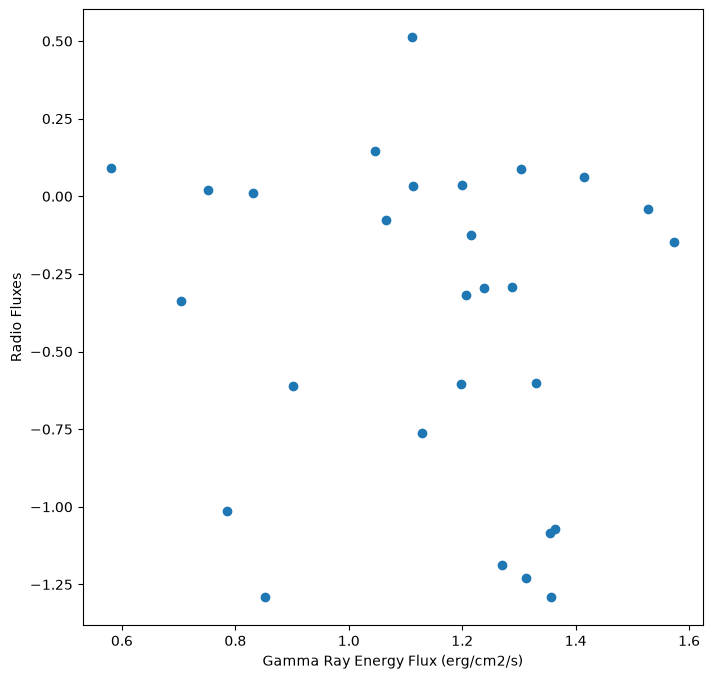

In [457]:
# scatter plot of 
plt.figure(figsize=(8,8))
plt.scatter(fermi_alphas, radio_alphas)
plt.xlabel('Gamma Ray Energy Flux (erg/cm2/s)')
plt.ylabel('Radio Fluxes')
plt.show()

<>:65: SyntaxWarning: invalid escape sequence '\G'
<>:65: SyntaxWarning: invalid escape sequence '\G'
C:\Users\mario\AppData\Local\Temp\ipykernel_31612\2607131264.py:65: SyntaxWarning: invalid escape sequence '\G'
  plt.xlabel('Gamma-Ray Photon Index ($\Gamma - 1$)')


PSR
BLL
BLL
FSRQ
FSRQ
AGN
FSRQ
PSR
BLL
BLL
FSRQ
BLL
BLL
FSRQ
FSRQ
BLL
FSRQ
FSRQ
BLL
FSRQ
BLL
PSR
PSR
FSRQ
PSR
FSRQ
BLL
FSRQ
FSRQ


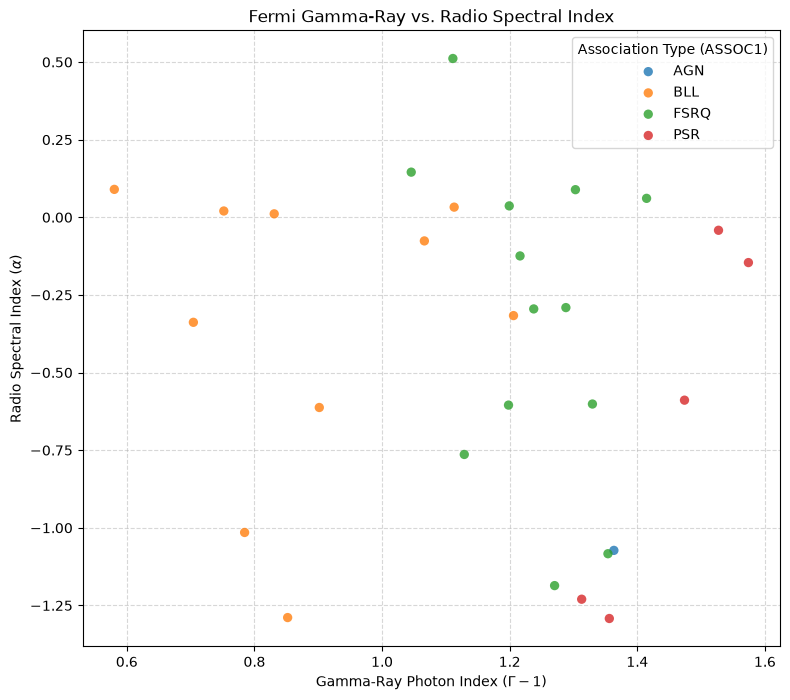

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your predefined list of expected uppercase Fermi LAT association classes

radio_alphas = []
fermi_alphas = []
assoc_categories = []  # To store the matched categories

for source in matched_associated_ellipses_spec_valid:
    # Extract Fermi Gamma-Ray Index
    if source[0]['SpectrumType'] == 'LogParabola':
        fermi_alpha = source[0]['LP_Index'] - 1
    else:
        fermi_alpha = source[0]['PL_Index'] - 1
        
    # Extract Radio Spectral Index
    radio_alpha = source[1]['spectral_index']
    
    # Direct match against your uppercase list
    raw_assoc = source[0]['CLASS1']
    print(raw_assoc)
    if raw_assoc in associations_upper:
        matched_category = raw_assoc
    else:
        matched_category = 'OTHER'
        
    radio_alphas.append(radio_alpha)
    fermi_alphas.append(fermi_alpha)
    assoc_categories.append(matched_category)

# Convert to arrays for masking
fermi_alphas = np.array(fermi_alphas)
radio_alphas = np.array(radio_alphas)
assoc_categories = np.array(assoc_categories)

# plot
plt.figure(figsize=(9, 8))
cmap = plt.get_cmap('tab10')

# Extract unique classes actually present in the data to build a clean legend
unique_present_classes = np.unique(assoc_categories)

for i, cls in enumerate(unique_present_classes):
    mask = (assoc_categories == cls)
    
    if cls == 'OTHER':
        plot_color = 'gray'
        plot_zorder = 1
    else:
        plot_color = cmap(i % 10)
        plot_zorder = 2
        
    plt.scatter(
        fermi_alphas[mask], 
        radio_alphas[mask], 
        label=cls, 
        color=plot_color, 
        alpha=0.8, 
        edgecolors='none', 
        s=45,
        zorder=plot_zorder
    )

plt.xlabel('Gamma-Ray Photon Index ($\Gamma - 1$)')
plt.ylabel('Radio Spectral Index ($\\alpha$)')
plt.title('Fermi Gamma-Ray vs. Radio Spectral Index')

plt.legend(title="Association Type (ASSOC1)", loc="best", frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your predefined list of expected uppercase Fermi LAT association classes

radio_alphas = []
fermi_alphas = []
assoc_categories = []  # To store the matched categories

for source in matched_associated_ellipses_spec_valid:
    # Extract Fermi Gamma-Ray Index
    if source[0]['SpectrumType'] == 'LogParabola':
        fermi_alpha = source[0]['LP_Index'] - 1
    else:
        fermi_alpha = source[0]['PL_Index'] - 1
        
    # Extract Radio Spectral Index
    radio_alpha = source[1]['spectral_index']
    
    # Direct match against your uppercase list
    raw_assoc = source[0]['CLASS1']
    print(raw_assoc)
    if raw_assoc in associations_upper:
        matched_category = raw_assoc
    else:
        matched_category = 'OTHER'
        
    radio_alphas.append(radio_alpha)
    fermi_alphas.append(fermi_alpha)
    assoc_categories.append(matched_category)

# Convert to arrays for masking
fermi_alphas = np.array(fermi_alphas)
radio_alphas = np.array(radio_alphas)
assoc_categories = np.array(assoc_categories)

# plot
plt.figure(figsize=(9, 8))
cmap = plt.get_cmap('tab10')

# Extract unique classes actually present in the data to build a clean legend
unique_present_classes = np.unique(assoc_categories)

for i, cls in enumerate(unique_present_classes):
    mask = (assoc_categories == cls)
    
    if cls == 'OTHER':
        plot_color = 'gray'
        plot_zorder = 1
    else:
        plot_color = cmap(i % 10)
        plot_zorder = 2
        
    hb = plt.hist2d(
        fermi_alphas[mask], 
        radio_alphas[mask], 
        label=cls, 
        color=plot_color, 
        alpha=0.8, 
        edgecolors='none', 
        s=45,
        zorder=plot_zorder
        )
    cb = plt.colorbar(hb[3])
    cb.set_label('Number of Stars per Bin')
    
    
plt.xlabel('Gamma-Ray Photon Index ($\Gamma - 1$)')
plt.ylabel('Radio Spectral Index ($\\alpha$)')
plt.title('Fermi Gamma-Ray vs. Radio Spectral Index')

plt.legend(title="Association Type (ASSOC1)", loc="best", frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [ ]:
# spectral index call
model = models.Polynomial1D(degree=1)
fitter=fitting.LinearLSQFitter()
freq_pattern     = r'ref_freq_LSPW'
flux_pattern     = r'total_flux_LSPW'
flux_err_pattern = r'total_flux_e_LSPW'

best_fit_slopes = []
best_fit_intercepts = []
chi_values = [] 

# bayesian monte-carlo fitting of spectral indexes
# spec_fitter_mc(mals_all_spws_merged)

for region in matched_associated_ellipses_spec_valid:
    radio_counterparts = region[1:]
    flux_names = radio_counterparts['radio_flux_name']
    freqs = radio_counterparts['radio_freqs']
    fluxes = []
    for index, source in enumerate(radio_counterparts):
        comp_flux  = (source[index][flux_names[index]] *u.mJy).to(u.Jy)
        
    # make all the (x) freqs in order and (y) fluxes in order
    freq_names = [string for string in mals_source.colnames if  freq_pattern in string]
    flux_names = [string for string in mals_source.colnames if flux_pattern in string]
    # flux_err_names = [string for string in mals_source.colnames if flux_err_pattern in string]

    

    # regex call the flux names and make dimensionless
    flux_values = ([(src/u.mJy) for src in mals_source[flux_names] if src>0])
    flux_err_values = ([(src/u.mJy) for src in mals_source[flux_err_names] if src>0])
    freq_values = ([(src/u.MHz) for src in mals_source[freq_names] if src>0])
    
    try:
        best_fit = fitter(model, freq_values, flux_values)
        # leave the flux err calc for later!
        # chi_value = calc_reduced_chi_square(best_fit(freq_values), freq_values, flux_values, flux_err_values, len(freq_values), 1 )
        best_fit_slopes.append(best_fit.parameters[1] *u.dimensionless_unscaled)
        best_fit_intercepts.append(best_fit.parameters[0] *u.dimensionless_unscaled)
        # chi_values.append(chi_value *u.dimensionless_unscaled)
        # print(best_fit)
    except:
        # for sources with only a single freq capture
        best_fit_slopes.append(0.0 *u.dimensionless_unscaled)
        best_fit_intercepts.append(0.0*u.dimensionless_unscaled)
        # chi_values.append(0.0*u.dimensionless_unscaled)
        # come back to chi values they feel off!
        
mals_all_spws_merged.add_columns([best_fit_slopes,best_fit_intercepts,chi_values], names=('fit_alpha_slope', 'fit_start', 'chi_value'))


In [377]:
# 1 getting the flux ratios
flux_ratios = []
fermi_fluxes = []
radio_fluxes = []
# S1.4, Fint, Ftot
for source in matched_associated_ellipses:
    flux_name = source[1]['radio_flux_name']
    
    fermi_flux = source[0]['Energy_Flux100']
    comp_flux  = (source[1][flux_name] *u.mJy).to(u.Jy)
    
    # ratio in erg/Jy
    print(fermi_flux)
    print(comp_flux)
    flux_ratio = fermi_flux/comp_flux
    flux_ratios.append(flux_ratio)
    fermi_fluxes.append(fermi_flux)
    radio_fluxes.append(comp_flux.value)

    

3.589063e-11
0.00313 Jy
4.647376e-11
7.114800000000001 Jy
1.2821422e-10
2.3031 Jy
2.9173795e-11
0.1371 Jy
4.845088e-11
0.031101 Jy
4.845088e-11
0.7002 Jy
5.645763e-12
0.0024 Jy
6.4913276e-11
1.1507 Jy
1.7552588e-11
0.2721 Jy
1.8220711e-10
1.7266 Jy
5.2468342e-11
5.7162 Jy
7.722187e-12
0.0029 Jy
1.1509672e-10
0.0024 Jy
1.5831798e-11
0.003 Jy
3.4916632e-11
1.0667 Jy
1.5071736e-11
0.0219 Jy
4.1348803e-11
0.1824 Jy
5.5131347e-11
0.7293999999999999 Jy
9.72922e-11
0.7363 Jy
5.815118e-11
3.2201999999999997 Jy
4.043508e-10
0.03589 Jy
4.043508e-10
0.03589 Jy
1.14364195e-11
1.652628 Jy
1.14364195e-11
1.45919 Jy
1.14364195e-11
1.45919 Jy
1.410096e-10
0.21690500000000001 Jy
1.410096e-10
0.09803 Jy
1.410096e-10
0.09803 Jy
6.429335e-12
0.0044 Jy
1.0741619e-10
0.42969999999999997 Jy
3.89509e-11
0.6745 Jy
1.7874535e-10
0.07031699999999999 Jy
1.7874535e-10
0.07031699999999999 Jy
1.8509523e-10
0.312 Jy
1.293375e-10
0.08268600000000001 Jy
6.606347e-12
0.0032 Jy
1.1770353e-10
1.558 Jy
7.450323e-12
0.01 Jy

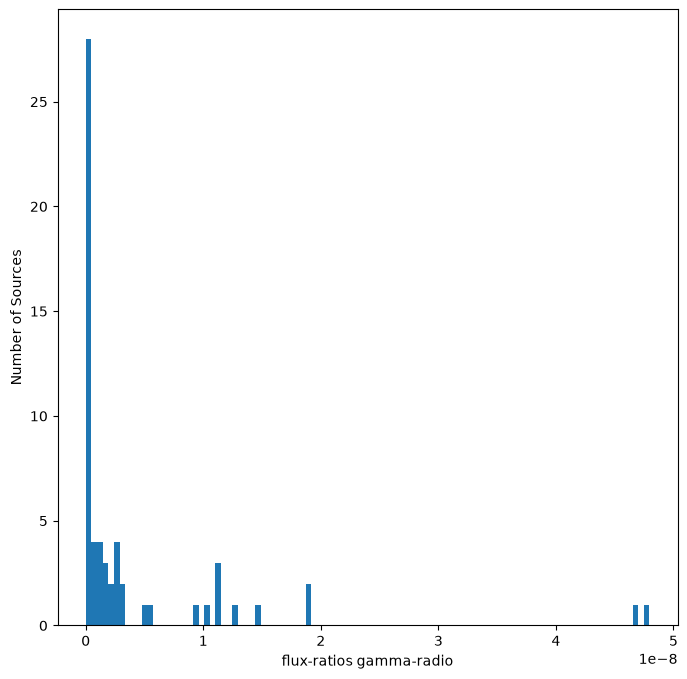

In [369]:
plt.figure(figsize=(8,8))
plt.hist(flux_ratios, bins=100)
plt.xlabel('flux-ratios gamma-radio')
plt.ylabel('Number of Sources')
plt.show()

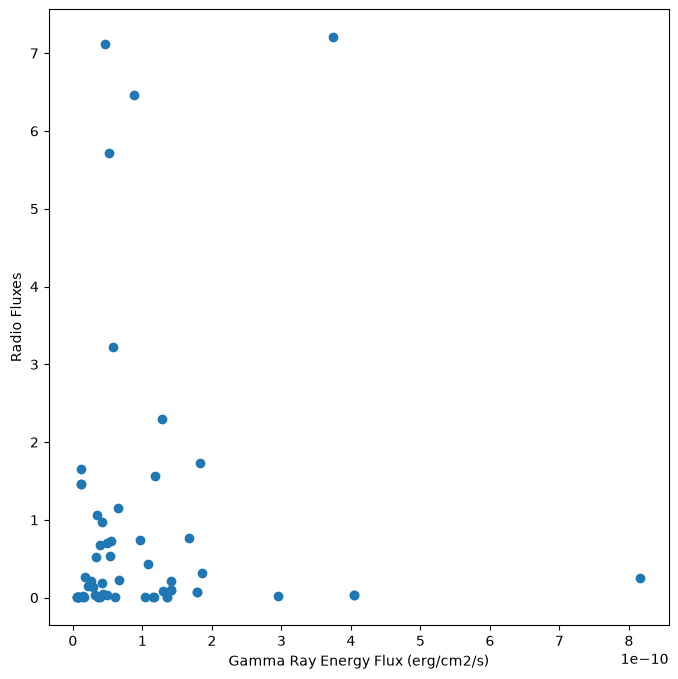

In [378]:

# scatter plot of 
plt.figure(figsize=(8,8))
plt.scatter(fermi_fluxes, radio_fluxes)
plt.xlabel('Gamma Ray Energy Flux (erg/cm2/s)')
plt.ylabel('Radio Fluxes')
plt.show()

In [259]:
fermi_alphas = []
for source in matched_associated_ellipses:
    if source[0]['SpectrumType'] == 'LogParabola':
        fermi_alpha = source[0]['LP_Index'] - 1

    else:
        fermi_alpha = source[0]['PL_Index'] - 1
    fermi_alphas.append(fermi_alpha)
    

Text(0, 0.5, 'radio alpha')

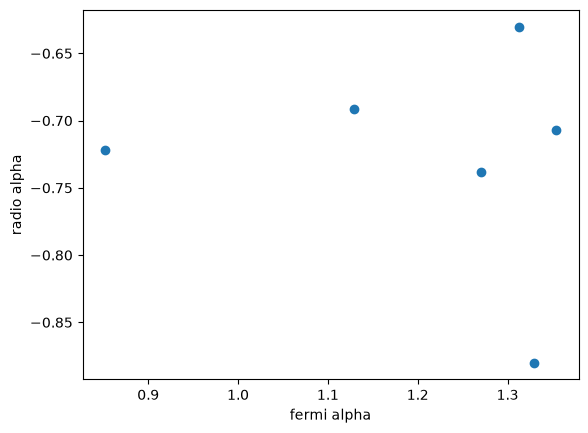

In [260]:
plt.scatter(fermi_alphas, alphas)
plt.xlabel('fermi alpha')
plt.ylabel('radio alpha')



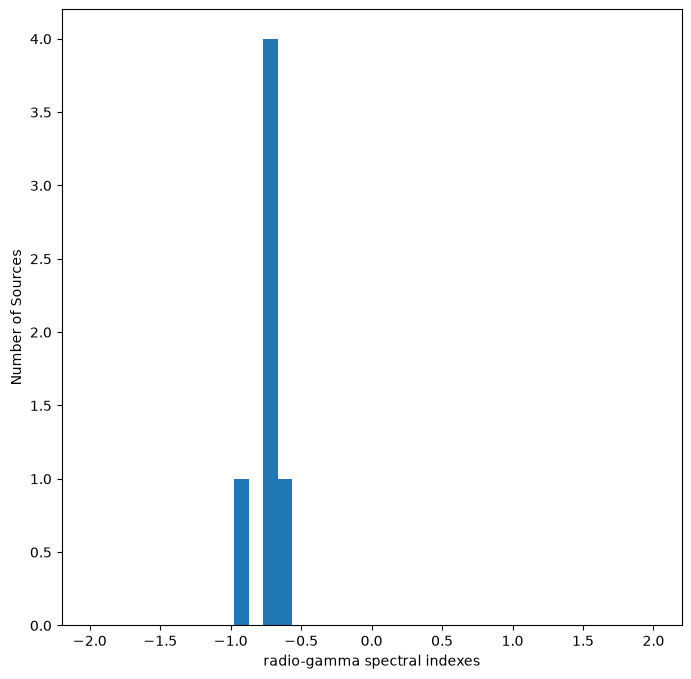

In [263]:
plt.figure(figsize=(8,8))
bin = np.linspace(-2, 2, 40)
plt.hist(alphas, bins=bin)
plt.xlabel('radio-gamma spectral indexes')
plt.ylabel('Number of Sources')
plt.show()

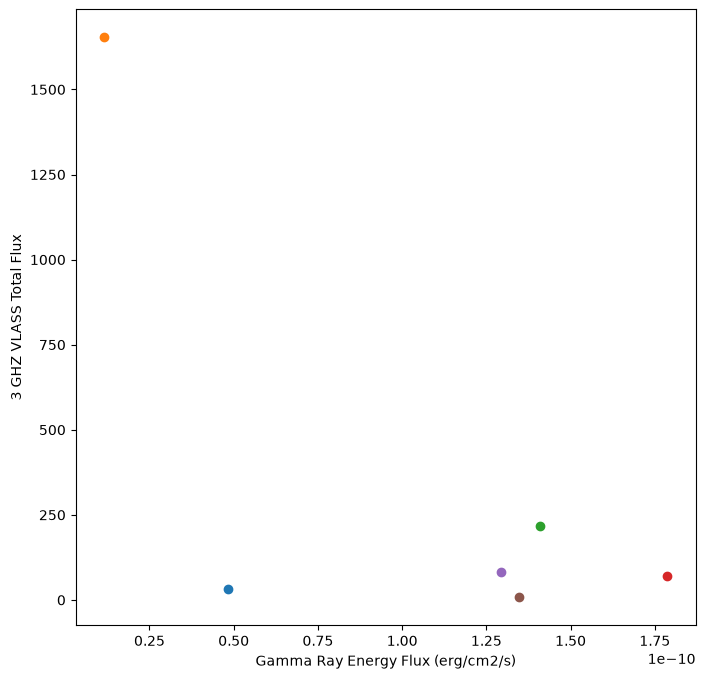

In [265]:
plt.figure(figsize=(8,8))
for source in matched_associated_ellipses:
    plt.scatter(source[0]['Energy_Flux100'], source[1]['Ftot'])
    plt.xlabel('Gamma Ray Energy Flux (erg/cm2/s)')
    plt.ylabel('3 GHZ VLASS Total Flux')
plt.show()

In [ ]:
# define all the data columns to analyze
# 1. gamma-radio spectral flux ratio (consider that the fermi source is uing gamma not alpha and that there gamm is positive! s prop v ^ - gamma
# 2. gamma-radio spectral index ratio (comparing which is greater i suppose...)
# 3. radio flux ratio (compactness quality)
# 3. scode of pysdbf source in numerical format (use the matches to see )
# 4. ngauss

# 5. trying with sources that are only <=-1 alpha

# these must all be get normalized 

In [ ]:
# create the convariance matrix 

In [ ]:
# get pc values an reduce to two dimensions

In [ ]:
# plot (optional)

In [ ]:
# make 2d density binning map!

question: would there be a stark differnce in the prior effectivness by only using sources matches in the same catalog year or no?

take advantage of using primary component analysis to boil down the most important aspects between fermi-mals and etc.
still require creation of known fermi-radio counterparts and then using that as a bin

In [ ]:
# take values (no codes? or we assign numerical counterparts for the codes) that are relvanat to compare for mals-fermi matches
# s_code, n_gauss, flux, spectral index, position from fermi source, pos_uncer?

# 
flux_ratio = bay_table_flux_prior[0]['FERMI_Total_flux']/bay_table_flux_prior[0]['FERMI_Total_flux']
spectral_index_ratio = ...

spectral_index_ratio = ...


In [ ]:
# standardize the value to limit bias across ranges

In [ ]:
# create covarince matrix and retrive eigenvalues and vectors

In [ ]:
# apply dimension reduction and state 

In [ ]:
# 

### K-tree and maching learning are next!